# Cross-variant, cross-state wave correlation

**Window: 2020-03 through 2026-08.** Ecological design: did states that ran unusually
high on one variant wave later run unusually high -- or low -- on a *different* variant
6-12 months on, relative to their peers? A signal like that would be consistent with
population-level immune interaction between variants playing out across states.

**Precondition**: this notebook needs a local copy of pango-designation's
`alias_key.json` at `data/pango_alias_key.json` (this cluster has no outbound internet,
so `pango_aliasor` can't fetch it itself). The setup cell below fails fast if it's
missing.

**Source data quirk**: `data/variants/outbreak_info_variants_states_long.csv` mixes two
row shapes -- national rows (`fips=="US"`) carry pre-computed proportions; state rows
carry only raw `lineage_count`. Every proportion used in this notebook is recomputed
from state-level counts after clustering, never read from the file's own `proportion`
column.

**Clustering is prevalence-gated, not a fixed depth cut**: a lineage only merges into
its Pango-tree parent if its own current cluster is still below a significance
threshold, capped at 2 climbs. A lineage that's already prevalent on its own (BA.5,
BQ.1, XBB.1.5, JN.1...) stays at its own designation regardless of depth -- every
collapse step dilutes the immune signal this analysis is after, so nothing collapses
unless it has to.

In [1]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import PercentFormatter

sys.path.insert(0, '.')
import variant_wave_data as vw

try:
    from IPython.display import display
except ImportError:
    display = print

pd.set_option('display.width', 220)
pd.set_option('display.max_columns', 40)

plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 150, 'font.size': 10,
    'axes.grid': True, 'grid.alpha': 0.25, 'axes.spines.top': False,
    'axes.spines.right': False, 'figure.facecolor': 'white',
})

RESULTS = f'{vw.WORKING_DIR}/data/results/variant_wave'
os.makedirs(RESULTS, exist_ok=True)

COL = {'pos': '#C2255C', 'neg': '#4C6EF5', 'neutral': '#868E96',
       'level': '#12866E', 'null': '#ADB5BD'}

aliasor = vw.load_aliasor()   # fails fast here if data/pango_alias_key.json is missing
print('alias file ok --', len(aliasor.alias_dict), 'registered aliases')

alias file ok -- 608 registered aliases


## 1. Coverage check

Confirm the two row shapes, and that dropping the handful of `lineage=NaN` rows doesn't silently lose real sequences.

In [2]:
raw = vw.load_variant_states_long()
national_df, state_df = vw.split_national_and_state_rows(raw)

print(f'{len(raw):,} rows total after dropping NaN-lineage rows')
print(f'{len(national_df):,} national rows, {len(state_df):,} state rows, {state_df.state.nunique()} states+DC')

# reconcile: state-level lineage_count should sum to ~ the national fips=="US" total
state_total = state_df['lineage_count'].sum()
national_total = national_df['lineage_count'].sum()
print(f'state-row total lineage_count: {state_total:,}')
print(f'national-row total lineage_count: {national_total:,}')
print(f'difference: {national_total - state_total:,} ({(national_total - state_total) / national_total:.4%} of national)')

load_variant_states_long: dropped 5 rows with lineage=NaN


split_national_and_state_rows: dropping 10864 territory rows (['AS', 'GU', 'MP', 'PR', 'VI'])
997,201 rows total after dropping NaN-lineage rows
205,897 national rows, 780,440 state rows, 51 states+DC
state-row total lineage_count: 3,694,175
national-row total lineage_count: 3,725,183
difference: 31,008 (0.8324% of national)


## 2. Weekly aggregation

Bucket the sparse daily rows to week-ending Saturday, and build the sequencing-volume denominator each state's share is computed against.

341,819 (state, lineage, week) rows -- 4,201 distinct raw lineages


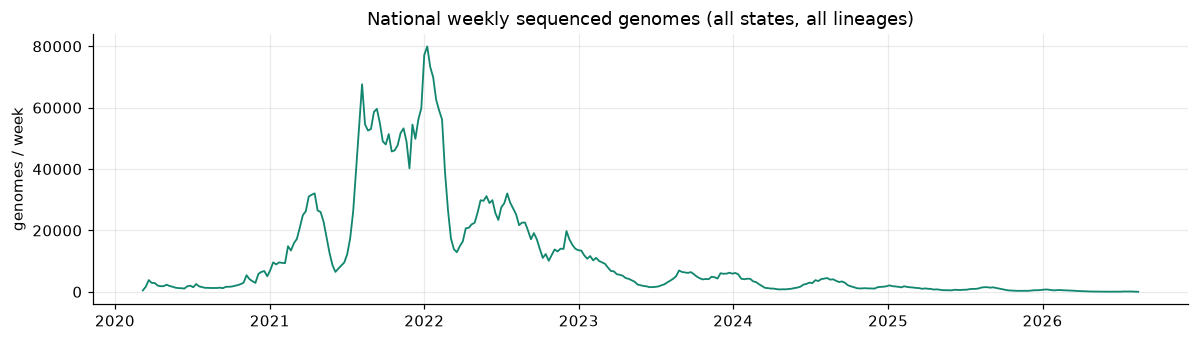

In [3]:
weekly_counts = vw.weekly_state_lineage_counts(state_df)
weekly_totals = vw.weekly_state_totals(weekly_counts)
print(f'{len(weekly_counts):,} (state, lineage, week) rows -- {weekly_counts.lineage.nunique():,} distinct raw lineages')

national_weekly_volume = weekly_totals.groupby('week_ending')['total_count'].sum()
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.plot(national_weekly_volume.index, national_weekly_volume.values, color=COL['level'], lw=1.2)
ax.set_title('National weekly sequenced genomes (all states, all lineages)')
ax.set_ylabel('genomes / week')
fig.tight_layout()
fig.savefig(f'{RESULTS}/01_national_weekly_volume.png')
plt.show()

## 3. Prevalence-aware collapsing sweep

Compute each raw lineage's own national peak share once, then sweep the significance threshold. Cluster count should shrink monotonically as the threshold rises; watch whether well-known major waves stay at `climbs=0` or start merging away.

In [4]:
lineage_prevalence = vw.raw_lineage_prevalence(weekly_counts, weekly_totals)
print(f'{len(lineage_prevalence):,} distinct raw lineages with a computed peak national share')

WATCH = ['BA.5', 'BQ.1.1', 'XBB.1.5', 'JN.1', 'KP.3.1.1', 'B.1.1.7']
sweep_rows = []
for thr in vw.SIGNIFICANCE_THRESHOLD_GRID:
    cmap, climbs = vw.build_prevalence_aware_clusters(aliasor, lineage_prevalence, significance_threshold=thr)
    n_other = sum(1 for v in cmap.values() if v == 'Other')
    row = {'significance_threshold': thr, 'n_clusters': len(set(cmap.values())),
           'n_lineages_in_Other': n_other}
    for l in WATCH:
        row[l] = cmap.get(l, '(not in data)')
    sweep_rows.append(row)
sweep_df = pd.DataFrame(sweep_rows)
display(sweep_df)

4,201 distinct raw lineages with a computed peak national share


,significance_threshold,n_clusters,n_lineages_in_Other,BA.5,BQ.1.1,XBB.1.5,JN.1,KP.3.1.1,B.1.1.7
0,0.005,1042,369,BA.5,BQ.1.1,XBB.1.5,JN.1,KP.3.1.1,B.1.1.7
1,0.010,638,431,BA.5,BQ.1.1,XBB.1.5,JN.1,KP.3.1.1,B.1.1.7
2,0.020,409,484,B.1.1.529,BQ.1.1,XBB.1.5,JN.1,KP.3.1.1,B.1.1.7
3,0.050,295,505,B.1.1,BQ.1.1,XBB.1.5,JN.1,KP.3.1.1,B.1.1.7


In [5]:
# max_climbs=1 vs 2 at the default threshold, as the plan's coarser-cap comparison
for mc in [1, 2]:
    cmap, _ = vw.build_prevalence_aware_clusters(aliasor, lineage_prevalence, max_climbs=mc)
    print(f'max_climbs={mc}: {len(set(cmap.values()))} clusters')

max_climbs=1: 726 clusters
max_climbs=2: 638 clusters


default (threshold=0.01, max_climbs=2): 638 clusters


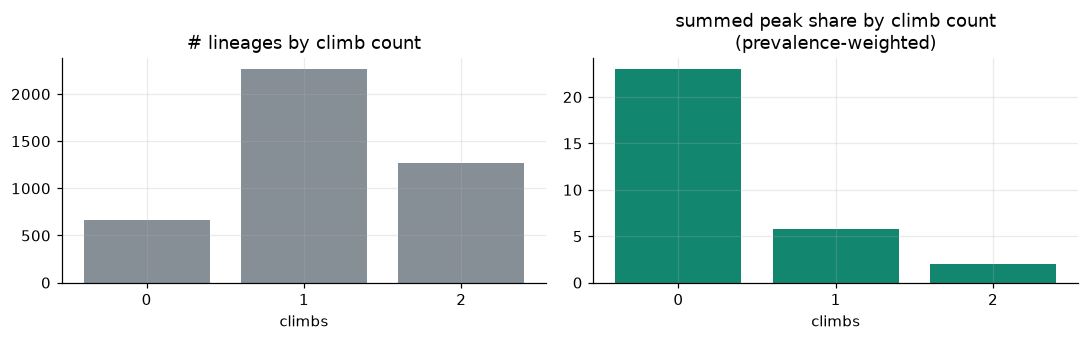

638 clusters after re-summing; 1.7% of (state,cluster,week) rows are Other


In [6]:
# default setting used for the rest of the notebook
cluster_map, climb_count = vw.build_prevalence_aware_clusters(aliasor, lineage_prevalence)
print(f'default (threshold={vw.DEFAULT_SIGNIFICANCE_THRESHOLD}, max_climbs={vw.MAX_CLIMBS}): '
      f'{len(set(cluster_map.values()))} clusters')

# climb-count distribution, weighted by each lineage's own prevalence -- confirms
# that most of the *volume* sits at climbs=0 (big, distinct lineages left alone)
# even though most of the long *tail* of rare lineages climbs away.
climb_series = pd.Series(climb_count)
prevalence_series = pd.Series(lineage_prevalence)
weighted = prevalence_series.groupby(climb_series).sum()
counts = climb_series.value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
axes[0].bar(counts.index.astype(str), counts.values, color=COL['neutral'])
axes[0].set_title('# lineages by climb count')
axes[1].bar(weighted.index.astype(str), weighted.values, color=COL['level'])
axes[1].set_title('summed peak share by climb count\n(prevalence-weighted)')
for ax in axes:
    ax.set_xlabel('climbs')
fig.tight_layout()
fig.savefig(f'{RESULTS}/02_climb_distribution.png')
plt.show()

weekly_counts_clustered = vw.clustered_weekly_counts(weekly_counts, cluster_map)
print(f'{weekly_counts_clustered.cluster.nunique()} clusters after re-summing; '
      f"{(weekly_counts_clustered.cluster == 'Other').mean():.1%} of (state,cluster,week) rows are Other")

## 4. Weak-state handling

Small states carry noisy per-state shares. Compare dropping them outright against pooling them into their Census Bureau division.

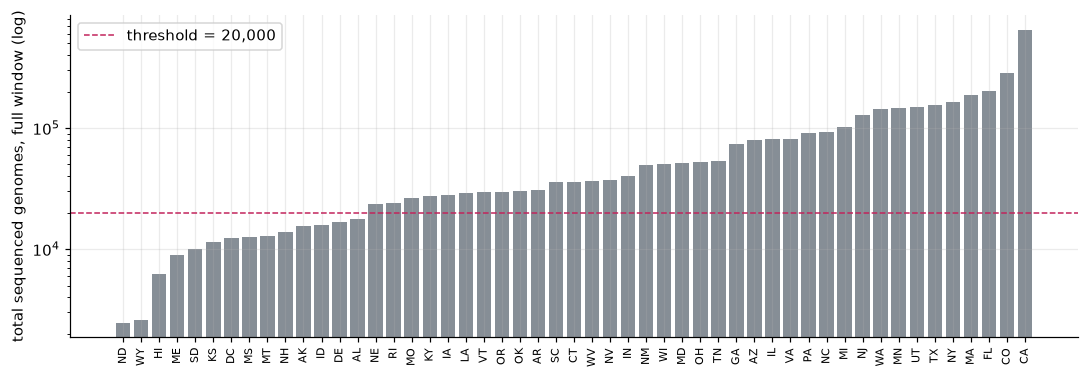

37 states/DC above threshold, 14 below: ['AK', 'AL', 'DC', 'DE', 'HI', 'ID', 'KS', 'ME', 'MS', 'MT', 'ND', 'NH', 'SD', 'WY']


In [7]:
strength = vw.state_signal_strength(weekly_totals)
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.bar(strength.index, strength.values, color=COL['neutral'])
ax.axhline(vw.DEFAULT_VOLUME_THRESHOLD, color=COL['pos'], ls='--', lw=1,
           label=f'threshold = {vw.DEFAULT_VOLUME_THRESHOLD:,}')
ax.set_yscale('log')
ax.set_ylabel('total sequenced genomes, full window (log)')
ax.tick_params(axis='x', rotation=90, labelsize=7)
ax.legend()
fig.tight_layout()
fig.savefig(f'{RESULTS}/03_state_volume.png')
plt.show()

strong, weak = vw.classify_states_by_volume(strength, vw.DEFAULT_VOLUME_THRESHOLD)
print(f'{len(strong)} states/DC above threshold, {len(weak)} below: {sorted(weak)}')

In [8]:
panel_drop, report_drop = vw.build_state_panel(weekly_counts_clustered, weekly_totals, mode='drop')
panel_pool, report_pool = vw.build_state_panel(weekly_counts_clustered, weekly_totals, mode='pool')
print('drop mode:', report_drop, '-- n geo:', panel_drop.geo.nunique())
print('pool mode:', report_pool, '-- n geo:', panel_pool.geo.nunique())

state_panel, weak_state_report = panel_pool, report_pool  # pool is the default for the rest of the notebook

# One color per geo, held constant across every plot in the notebook that
# breaks a series out by state -- lets the same state be tracked visually
# across separate subplots/figures instead of each one re-assigning colors
# from its own local top-N list.
_palette = (list(plt.get_cmap('tab20').colors) + list(plt.get_cmap('tab20b').colors)
            + list(plt.get_cmap('tab20c').colors))
STATE_COLORS = {g: _palette[i % len(_palette)] for i, g in enumerate(sorted(state_panel['geo'].unique()))}

drop mode: {'mode': 'drop', 'n_dropped': 14, 'dropped_states': ['AK', 'AL', 'DC', 'DE', 'HI', 'ID', 'KS', 'ME', 'MS', 'MT', 'ND', 'NH', 'SD', 'WY']} -- n geo: 37
pool mode: {'mode': 'pool', 'n_pooled': 14, 'pooled_states': ['AK', 'AL', 'DC', 'DE', 'HI', 'ID', 'KS', 'ME', 'MS', 'MT', 'ND', 'NH', 'SD', 'WY']} -- n geo: 43


## 5. Wave windows

National weekly share per cluster, recomputed post-clustering; peak week plus the half-max contiguous window around it defines each cluster's "wave." Clusters below the peak-share floor or with a single-week window are dropped as noise (verified empirically -- see module docstring on `build_wave_windows`).

In [9]:
national_cluster_shares = vw.national_weekly_cluster_shares(
    vw.assign_clusters(weekly_counts, cluster_map), weekly_totals, group_col='cluster')
wave_windows = vw.build_wave_windows(national_cluster_shares)
print(f'{len(wave_windows)} clusters retained as waves (of {weekly_counts_clustered.cluster.nunique()} clusters)')
display(wave_windows.sort_values('peak_share', ascending=False).head(15))

439 clusters retained as waves (of 638 clusters)


,cluster,peak_week,peak_share,window_start,window_end
24,B.1,2020-05-09,0.756999,2020-03-14,2020-08-01
71,BA.1.1,2022-02-19,0.702062,2022-01-01,2022-03-19
345,XBB.1.5,2023-03-11,0.701595,2023-01-21,2023-05-27
35,B.1.1.7,2021-05-08,0.660797,2021-03-20,2021-06-19
79,BA.2.12.1,2022-05-28,0.595148,2022-04-30,2022-06-25
77,BA.2,2022-04-09,0.532071,2022-03-19,2022-05-21
38,B.1.2,2020-11-21,0.491025,2020-10-03,2021-02-27
165,JN.1,2024-01-27,0.414003,2023-12-23,2024-03-30
200,KP.3.1.1,2024-09-28,0.363039,2024-08-17,2024-12-07
380,XFG.1.1,2026-05-09,0.303371,2026-05-09,2026-05-16


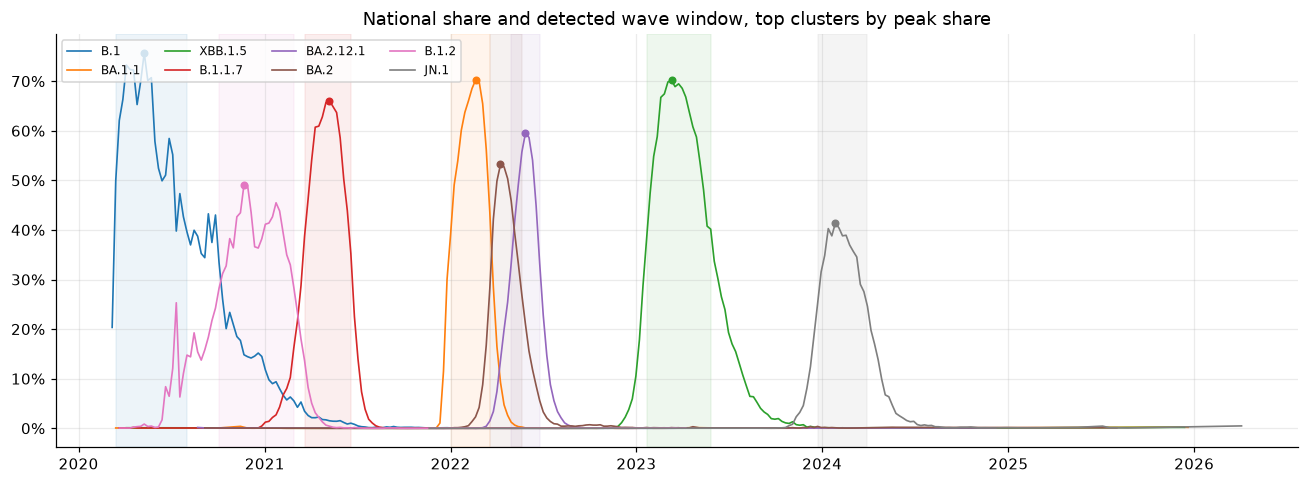

In [10]:
top_clusters = wave_windows.sort_values('peak_share', ascending=False).head(8)['cluster'].tolist()
fig, ax = plt.subplots(figsize=(12, 4.5))
cmap = plt.get_cmap('tab10')
for i, cl in enumerate(top_clusters):
    s = national_cluster_shares[national_cluster_shares.cluster == cl].set_index('week_ending')['share']
    w = wave_windows.set_index('cluster').loc[cl]
    ax.plot(s.index, s.values, label=cl, color=cmap(i % 10), lw=1.1)
    ax.axvspan(w['window_start'], w['window_end'], color=cmap(i % 10), alpha=0.08)
    ax.scatter([w['peak_week']], [w['peak_share']], color=cmap(i % 10), s=18, zorder=5)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_title('National share and detected wave window, top clusters by peak share')
ax.legend(ncol=4, fontsize=8, loc='upper left')
fig.tight_layout()
fig.savefig(f'{RESULTS}/04_wave_windows.png')
plt.show()

## 6. Relative levels (z-scores)

For each (state, cluster), the state's mean share over that cluster's wave window, standardized across states -- the value everything downstream correlates on.

18,877 (geo, cluster) rows, 43 geos, 439 clusters


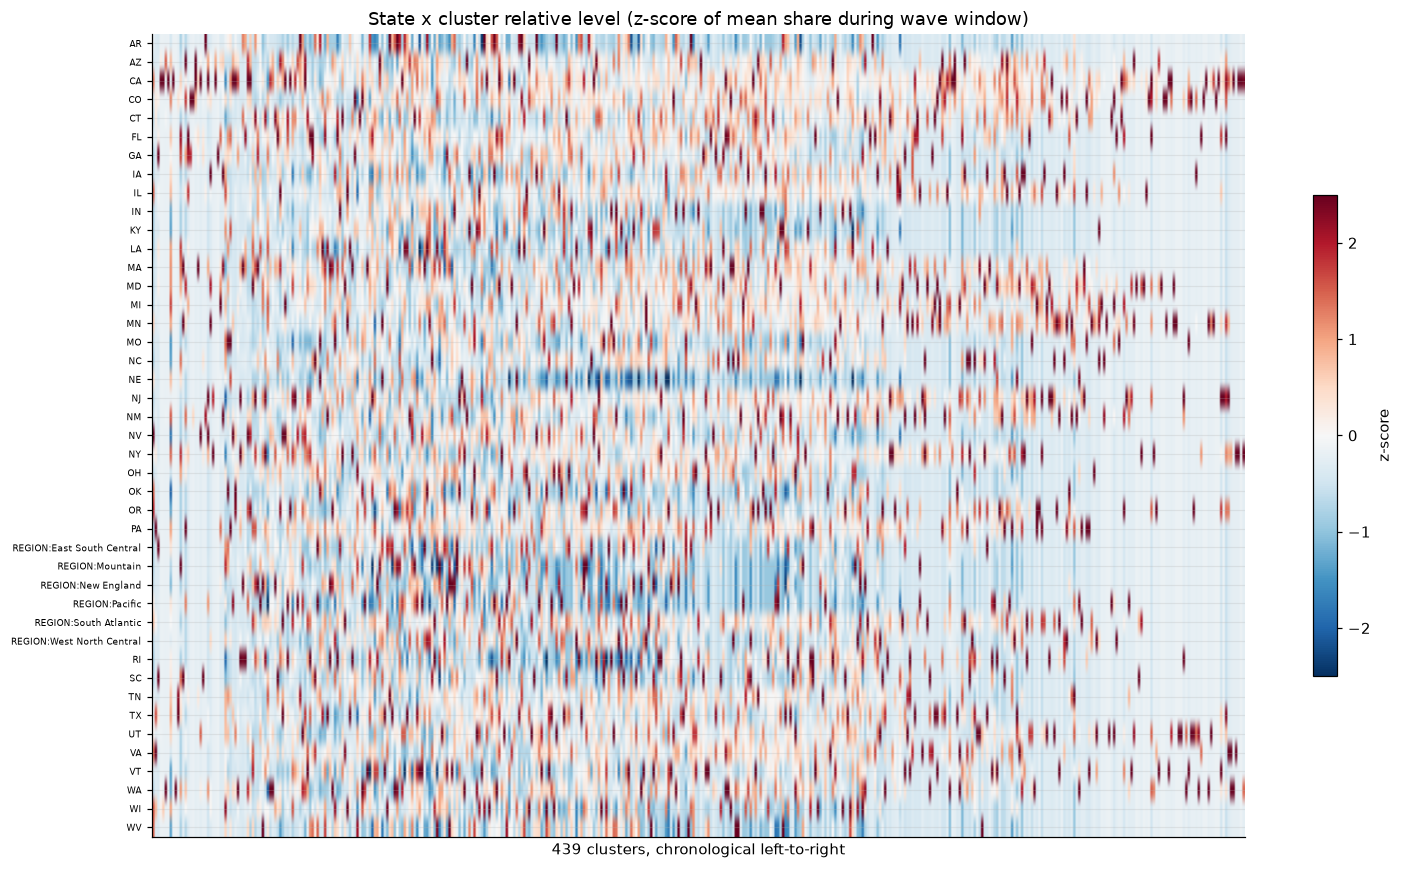

In [11]:
relative_level = vw.relative_level_zscore(state_panel, wave_windows)
print(f'{len(relative_level):,} (geo, cluster) rows, {relative_level.geo.nunique()} geos, {relative_level.cluster.nunique()} clusters')

pivot = relative_level.pivot_table(index='geo', columns='cluster', values='zscore')
order = wave_windows.set_index('cluster').loc[pivot.columns, 'peak_week'].sort_values().index
pivot = pivot[order]
fig, ax = plt.subplots(figsize=(14, 8))
im = ax.imshow(pivot.values, aspect='auto', cmap='RdBu_r', vmin=-2.5, vmax=2.5)
ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index, fontsize=6)
ax.set_xticks([]); ax.set_xlabel(f'{pivot.shape[1]} clusters, chronological left-to-right')
ax.set_title('State x cluster relative level (z-score of mean share during wave window)')
fig.colorbar(im, ax=ax, shrink=0.6, label='z-score')
fig.tight_layout()
fig.savefig(f'{RESULTS}/05_relative_level_heatmap.png')
plt.show()

## 7. Primary correlation: data-driven peak pairing

Only test ordered cluster pairs whose *national* peaks fall naturally 6-12 months apart, then Spearman-correlate their per-state relative levels across states. Benjamini-Hochberg FDR correction across all tested pairs.

In [12]:
pairs = vw.candidate_pairs_by_peak_gap(wave_windows)
print(f'{len(pairs):,} candidate pairs with a natural 6-12 month peak gap')

corr_table = vw.correlation_table(relative_level, pairs)
corr_table = vw.add_fdr_correction(corr_table)
print(f'{corr_table.fdr_significant.sum()} pairs significant at FDR < {vw.FDR_ALPHA} '
      f'(of {corr_table.spearman_r.notna().sum()} testable pairs)')

top_hits = (corr_table.dropna(subset=['spearman_r'])
            .reindex(corr_table.spearman_r.abs().sort_values(ascending=False).index)
            .head(20))
display(top_hits[['cluster_x', 'cluster_y', 'lag_months', 'n_states', 'spearman_r', 'p_value', 'q_value', 'fdr_significant']])

13,819 candidate pairs with a natural 6-12 month peak gap


575 pairs significant at FDR < 0.05 (of 13819 testable pairs)


,cluster_x,cluster_y,lag_months,n_states,spearman_r,p_value,q_value,fdr_significant
10190,R.1,BA.1.18,10.118265,43,0.812199,3.821101e-11,5.280379e-07,True
9771,PQ.10,RC.6,11.038108,43,0.804688,7.908804e-11,5.464588e-07,True
13618,XFG.9.4,PQ.17.12,6.898817,43,0.773304,1.215222e-09,5.597719e-06,True
13543,XFG.9.1,RV.1,7.358739,43,0.755015,4.928687e-09,1.702738e-05,True
13764,XFP,RF.4,11.038108,43,0.741812,1.258631e-08,3.060878e-05,True
289,AY.14,BA.5.5,11.957950,43,-0.740109,1.414691e-08,3.060878e-05,True
13519,XFG.8.1,XFG.1.1,6.438896,43,0.738764,1.550485e-08,3.060878e-05,True
822,B.1.1.7,BA.1,7.588699,43,-0.733766,2.169004e-08,3.746682e-05,True
8107,MC.16,XFG.5.1.4,10.808147,43,0.731569,2.508138e-08,3.851106e-05,True
1962,BA.2.3,BQ.1.1.32,8.968463,43,0.723950,4.106127e-08,5.674257e-05,True


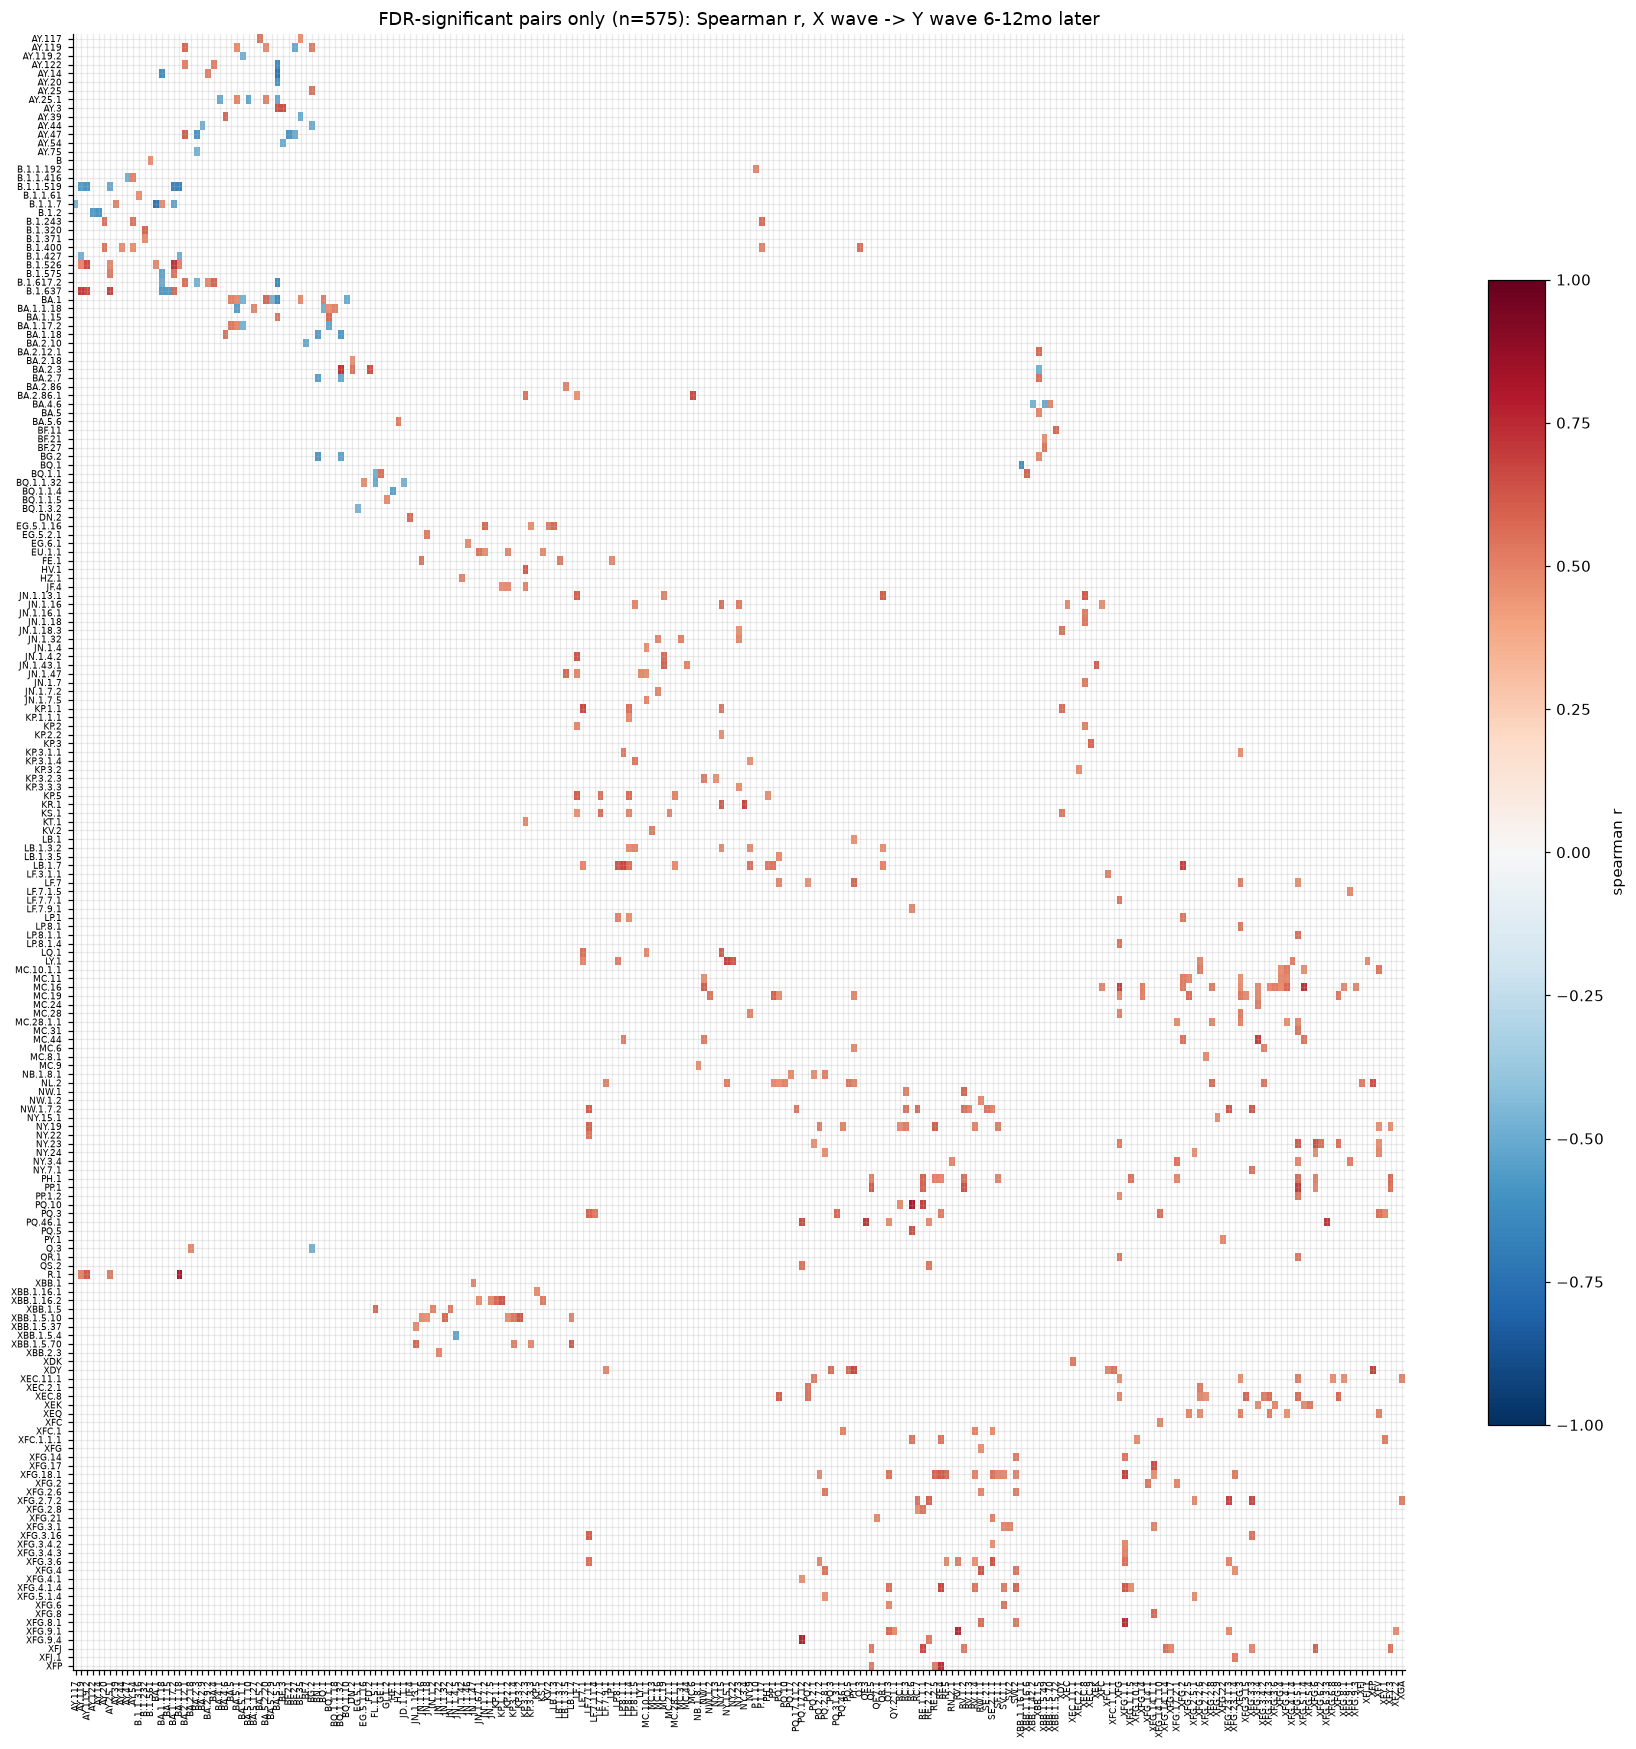

In [13]:
sig = corr_table[corr_table.fdr_significant].copy()
if len(sig):
    heat = sig.pivot_table(index='cluster_x', columns='cluster_y', values='spearman_r')
    fig, ax = plt.subplots(figsize=(min(0.35 * heat.shape[1] + 3, 16), min(0.35 * heat.shape[0] + 3, 16)))
    im = ax.imshow(heat.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    ax.set_xticks(range(heat.shape[1])); ax.set_xticklabels(heat.columns, rotation=90, fontsize=6)
    ax.set_yticks(range(heat.shape[0])); ax.set_yticklabels(heat.index, fontsize=6)
    ax.set_title(f'FDR-significant pairs only (n={len(sig)}): Spearman r, X wave -> Y wave 6-12mo later')
    fig.colorbar(im, ax=ax, shrink=0.7, label='spearman r')
    fig.tight_layout()
    fig.savefig(f'{RESULTS}/06_significant_pairs_heatmap.png')
    plt.show()
else:
    print('no FDR-significant pairs at the default clustering settings')

## 8. Variant search: overlays for every significant pair involving a chosen lineage

Set `VARIANT_QUERY` below to any lineage name (raw or already-collapsed cluster label).
This finds every FDR-significant pair where that lineage -- or a true descendant of it --
appears as X or Y, and plots a state-share overlay for each.

Matching is done in fully dealiased Pango-tree space via `pango_aliasor`
(`vw.matches_lineage`), not string prefix: `"JN.1"` also catches a descendant like
`KP.3.1.1`, which picked up its own alias letter and doesn't share "JN.1" as a text
prefix at all, but *is* a true descendant once both are dealiased. A literal
`cluster.startswith("JN.1")` check would silently miss cases like that.

**Reading these plots**: each pair's two panels show the *same* set of states --
whichever were most extreme (highest and lowest z-score) on the cluster that
actually matched `VARIANT_QUERY` (not always `cluster_x`; a pair can pull the query
match in as either side), restricted up front to states with genuine signal in
*both* clusters so nothing picked on one side can silently vanish from the other --
in the *same* colors in both panels (`STATE_COLORS`, fixed once state_panel is
built). Anchoring on the query match rather than whichever side happens to be
`cluster_x` also means every pair sharing that same matched cluster reuses the same
state roster, instead of a fresh, mostly-disjoint cast for every single pair. A
dashed black line (drawn on top, so it can't get buried under the colored state
lines) marks the national average in both panels, so each state's line can be read
as its degree of departure from the national trend, not just its raw level.

If `spearman_r` is real, a state that stands out from the national average in the
left panel should stand out (same direction for positive r, opposite for negative r)
in the right panel too; if the colored lines sit clearly off the dashed line on the
left but scatter randomly around it on the right, that's what a near-zero
correlation looks like. Waves with a very high, near-universal national peak share
(e.g. XBB.1.5 at ~70%) leave little real between-state variance to standardize in
the first place, so their z-scores -- and any correlation built on them -- are
weaker by construction, not by bug.

In [14]:
# Note on scope: a query near the root of a big radiating family matches everything
# below it, so plot count grows fast -- e.g. 'BQ.1.1' matches ~7 clusters/~19 pairs,
# but 'JN.1' (root of the still-diversifying 2024-2026 JN/KP/LB/LF/LP/MC/NY family)
# matches 100+ clusters and ~290 significant pairs. That's not a bug, just how wide
# that particular family's tree is; narrow the query (e.g. 'KP.3' instead of 'JN.1')
# for a smaller, more targeted set of plots.
VARIANT_QUERY = 'JN.1'  # <-- change this to search a different lineage or family

matching_clusters = vw.find_matching_clusters(aliasor, wave_windows['cluster'], VARIANT_QUERY)
print(f'{VARIANT_QUERY!r} matches {len(matching_clusters)} retained cluster(s): {matching_clusters}')

query_pairs = sig[sig.cluster_x.isin(matching_clusters) | sig.cluster_y.isin(matching_clusters)]
query_pairs = query_pairs.reindex(query_pairs.spearman_r.abs().sort_values(ascending=False).index)
print(f'{len(query_pairs)} FDR-significant pair(s) involve {VARIANT_QUERY!r}')
display(query_pairs[['cluster_x', 'cluster_y', 'lag_months', 'n_states', 'spearman_r', 'p_value', 'q_value']])

'JN.1' matches 111 retained cluster(s): ['JN.1', 'JN.1.1', 'JN.1.11.1', 'JN.1.13.1', 'JN.1.16', 'JN.1.16.1', 'JN.1.18', 'JN.1.18.3', 'JN.1.2', 'JN.1.22', 'JN.1.32', 'JN.1.39', 'JN.1.4', 'JN.1.4.2', 'JN.1.4.5', 'JN.1.42', 'JN.1.43.1', 'JN.1.46', 'JN.1.47', 'JN.1.52', 'JN.1.67.1', 'JN.1.7', 'JN.1.7.2', 'JN.1.7.5', 'JN.1.8.1', 'JN.1.9', 'KP.1.1', 'KP.1.1.1', 'KP.1.1.3', 'KP.1.1.5', 'KP.2', 'KP.2.2', 'KP.2.3', 'KP.3', 'KP.3.1', 'KP.3.1.1', 'KP.3.1.4', 'KP.3.2', 'KP.3.2.3', 'KP.3.3', 'KP.3.3.3', 'KP.5', 'KQ.1', 'KR.1', 'KS.1', 'KV.2', 'LB.1', 'LB.1.2', 'LB.1.3', 'LB.1.3.1', 'LB.1.3.2', 'LB.1.3.5', 'LB.1.7', 'LF.3.1.1', 'LF.7', 'LF.7.1', 'LF.7.1.5', 'LF.7.11', 'LF.7.11.4', 'LF.7.7.1', 'LF.7.9.1', 'LP.1', 'LP.8.1', 'LP.8.1.1', 'LP.8.1.4', 'LP.8.1.5', 'LQ.1', 'LY.1', 'MC.1', 'MC.10.1', 'MC.10.1.1', 'MC.11', 'MC.13', 'MC.16', 'MC.19', 'MC.2', 'MC.21.1', 'MC.24', 'MC.28', 'MC.28.1.1', 'MC.31', 'MC.44', 'MC.6', 'MC.8.1', 'MC.9', 'NL.2', 'NW.1', 'NW.1.2', 'NW.1.7.2', 'NY.13', 'NY.15', 'NY.15.1', '

,cluster_x,cluster_y,lag_months,n_states,spearman_r,p_value,q_value
13764,XFP,RF.4,11.038108,43,0.741812,1.258631e-08,0.000031
8107,MC.16,XFG.5.1.4,10.808147,43,0.731569,2.508138e-08,0.000039
9645,PP.1,XFG.5.1,6.438896,43,0.701958,1.562662e-07,0.000144
8480,MC.44,XFG.3.4,11.957950,43,0.691875,2.772832e-07,0.000239
8088,MC.16,XFG,11.727989,43,0.688301,3.379315e-07,0.000261
...,...,...,...,...,...,...,...
7316,LF.7,PQ.2,7.358739,43,0.458438,1.990521e-03,0.048560
2092,BA.2.86.1,LF.7,11.498029,43,0.458324,1.996340e-03,0.048560
10755,XBB.1.5.10,JN.1.18,8.278581,43,0.458263,1.999464e-03,0.048560
6823,KS.1,LF.7,7.128778,43,0.457438,2.042071e-03,0.049364


In [15]:
strings_vector = ['JN.1','JN.1.18']  # <-- change this to search for different variants
filtered_query_pairs = query_pairs[
    query_pairs["cluster_y"].str.contains("|".join(strings_vector), na=False)
]
query_pairs = filtered_query_pairs
query_pairs

,cluster_x,cluster_y,lag_days,lag_months,n_states,spearman_r,p_value,q_value,fdr_significant
4013,EG.5.1.16,JN.1.7.2,210,6.898817,43,0.574991,0.000055,0.007115,True
11123,XBB.1.5.70,JN.1.13.1,210,6.898817,43,0.573674,0.000058,0.007263,True
10758,XBB.1.5.10,JN.1.32,259,8.508541,43,0.570378,0.000065,0.007699,True
4290,EU.1.1,JN.1.67.1,343,11.268068,43,0.538111,0.000198,0.014185,True
4340,FE.1,JN.1.16,315,10.348226,43,0.532240,0.000239,0.015404,True
10698,XBB.1.5,JN.1.4.2,315,10.348226,43,0.521610,0.000335,0.018641,True
4180,EG.5.2.1,JN.1.18,252,8.278581,43,0.520944,0.000342,0.018878,True
11067,XBB.1.5.4,JN.1.4.5,294,9.658344,43,-0.520813,0.000343,0.018879,True
4907,HZ.1,JN.1.42,259,8.508541,43,0.497349,0.000691,0.028092,True
10694,XBB.1.5,JN.1.2,294,9.658344,43,0.495007,0.000739,0.028456,True


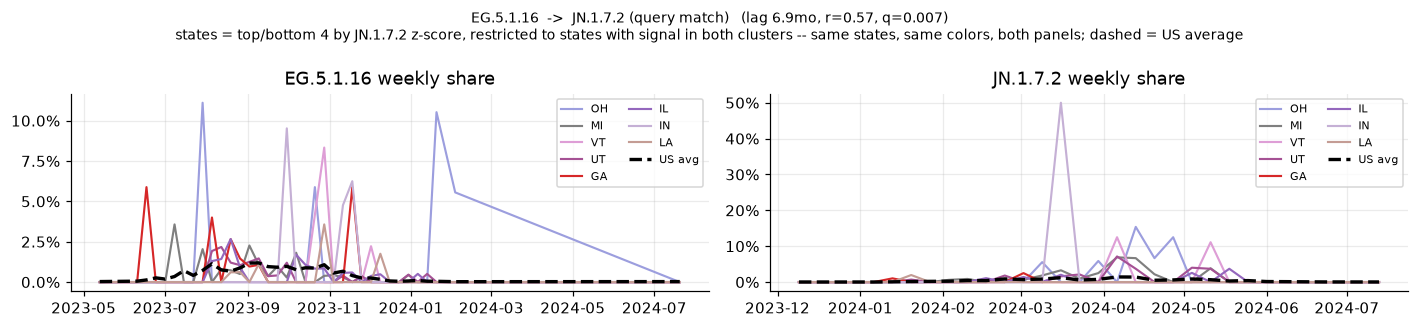

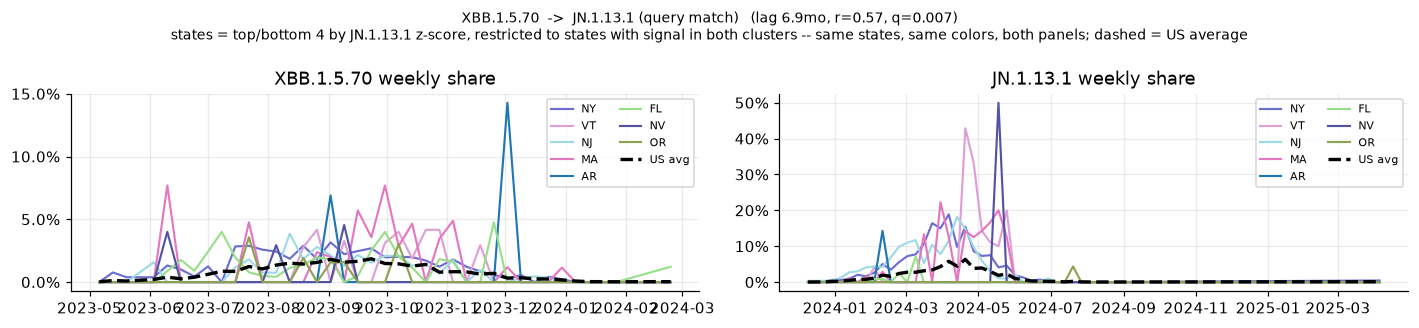

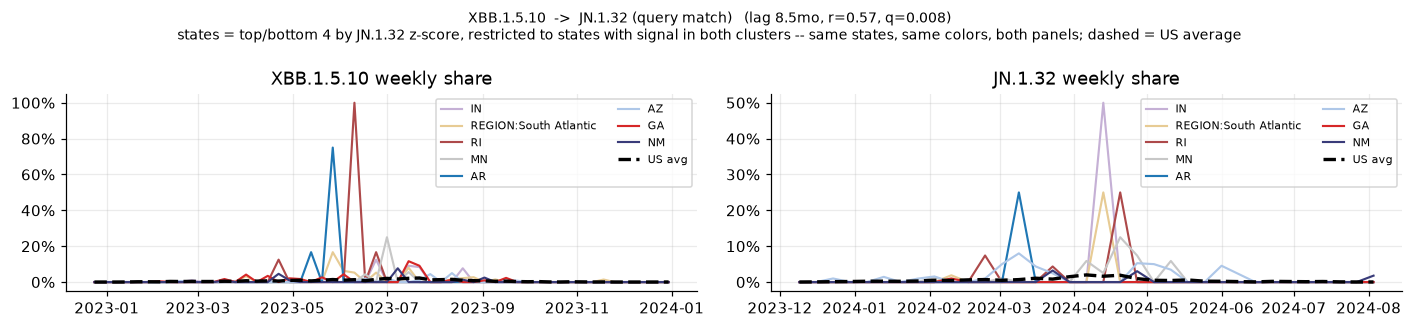

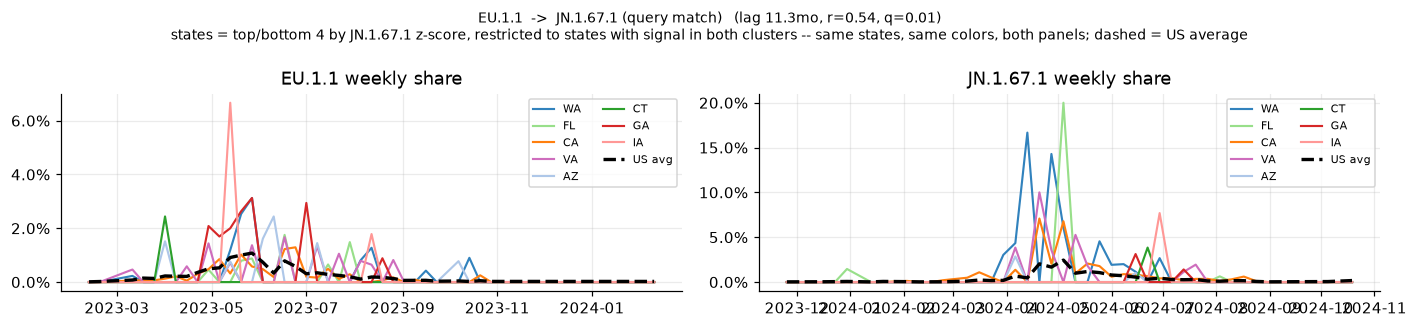

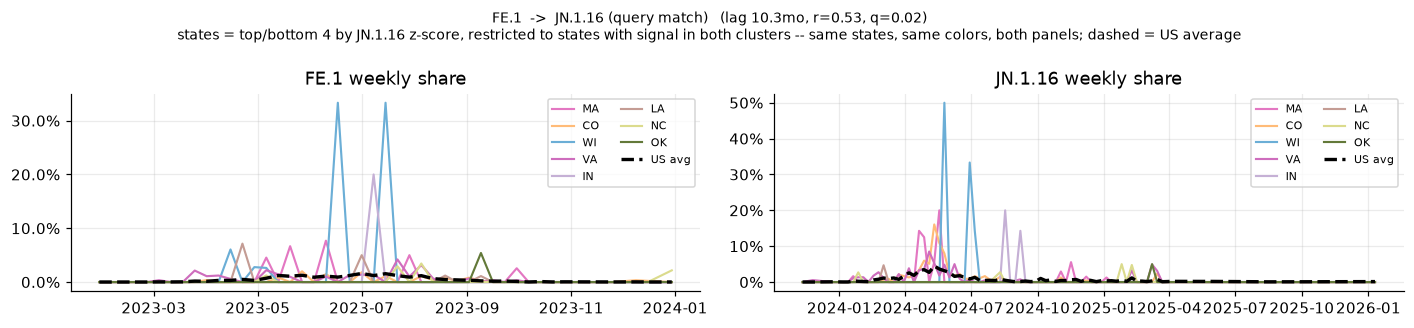

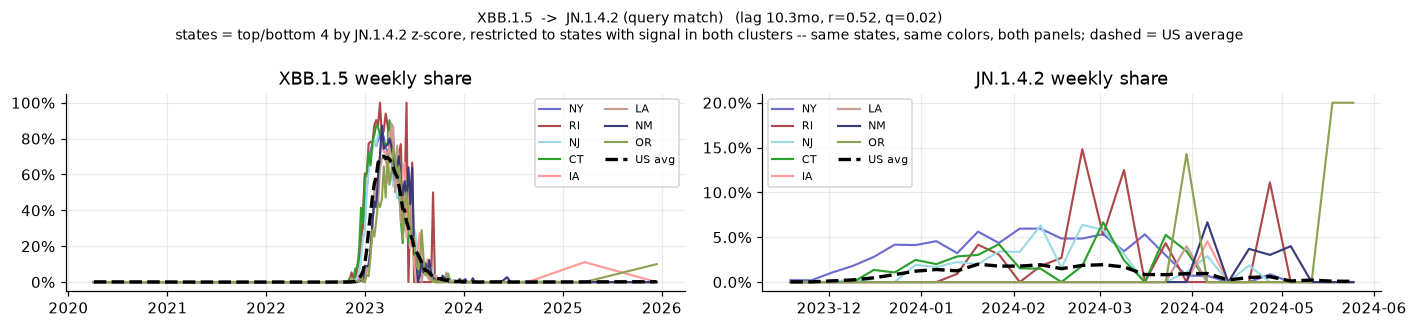

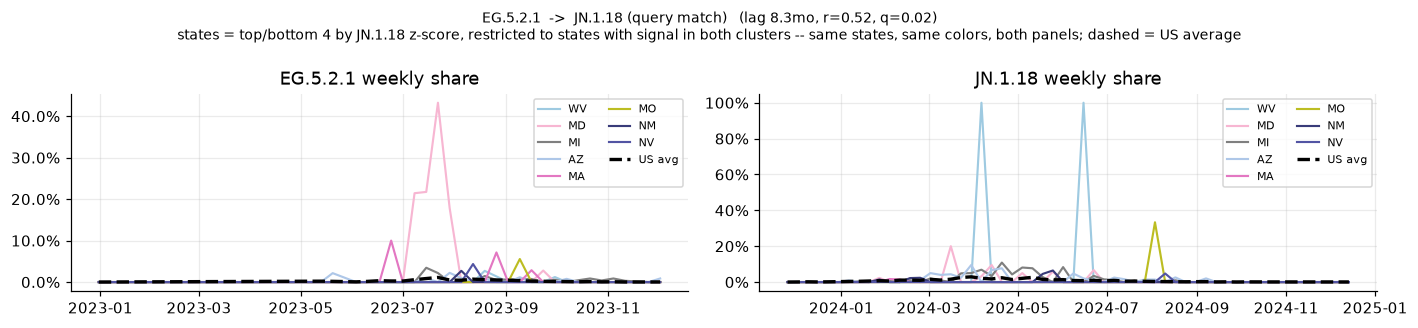

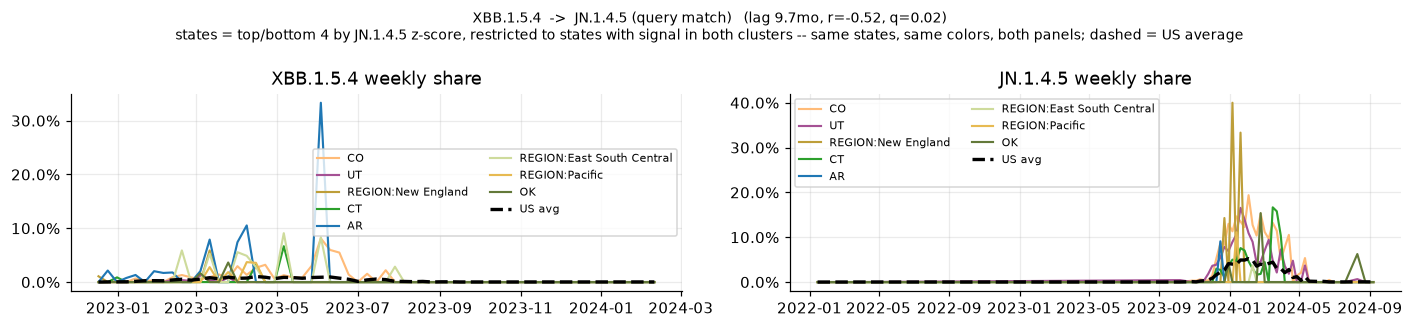

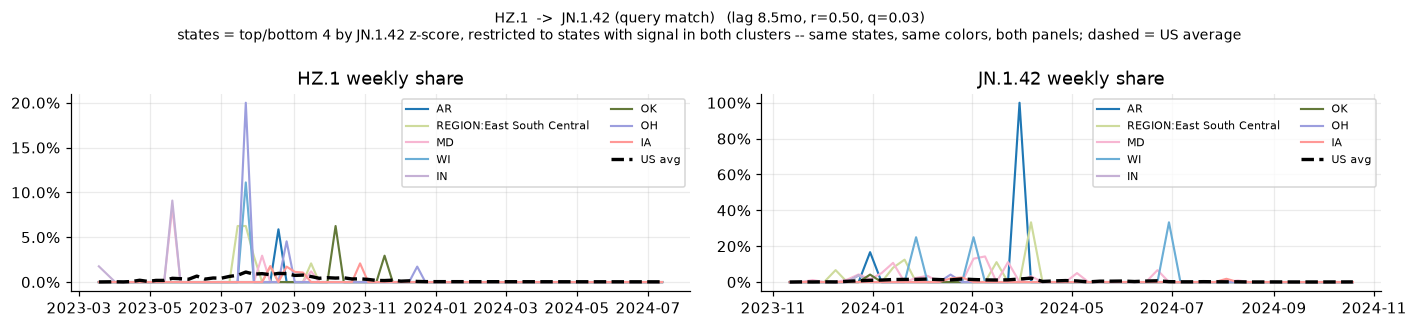

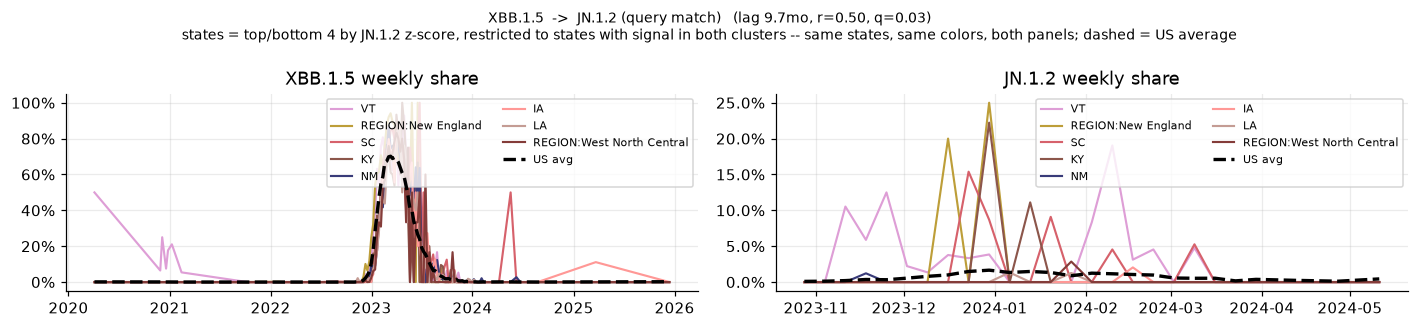

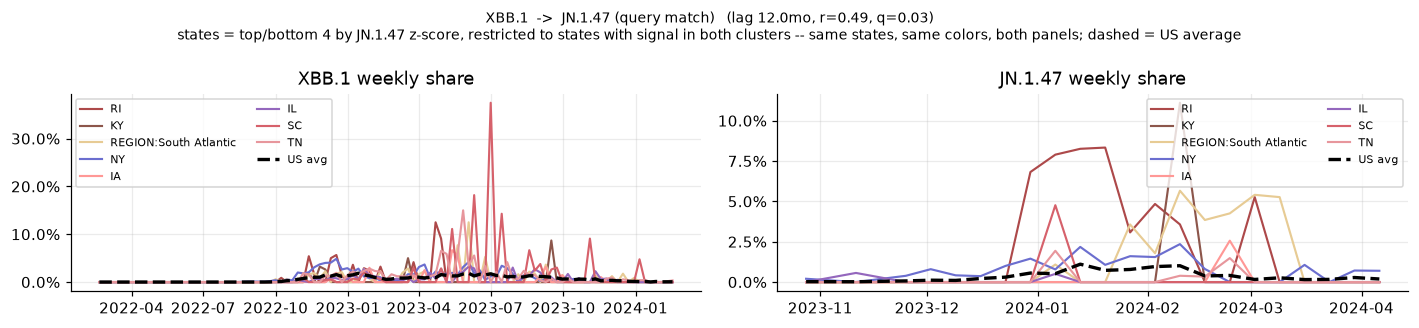

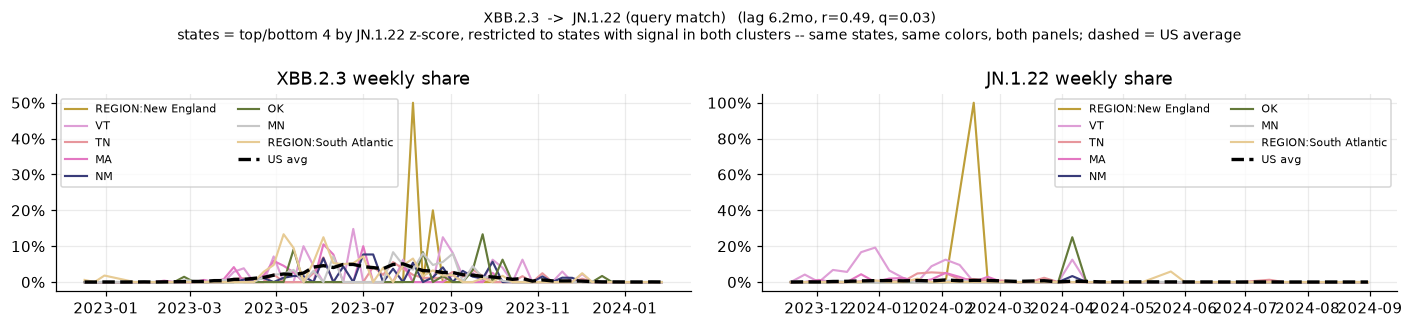

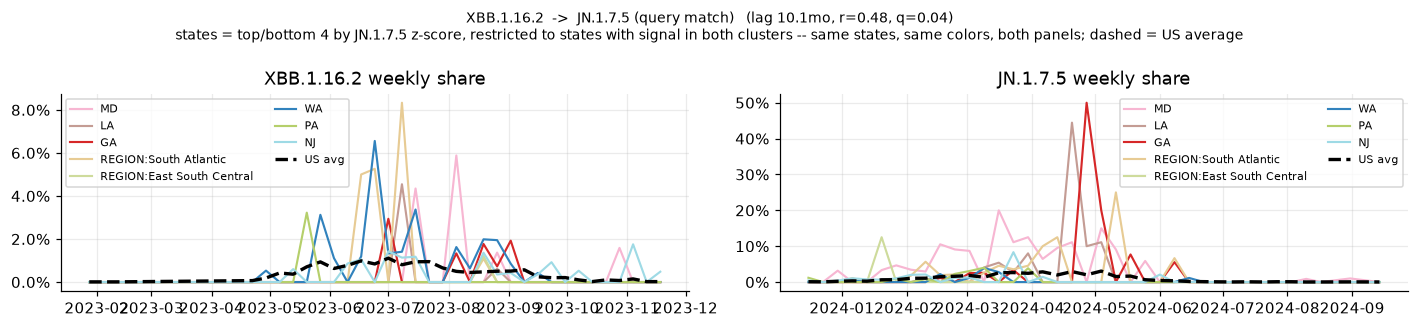

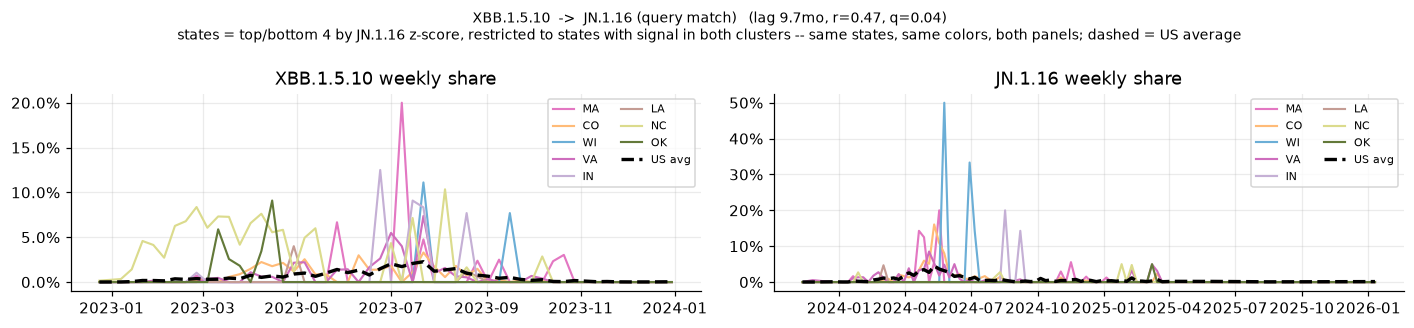

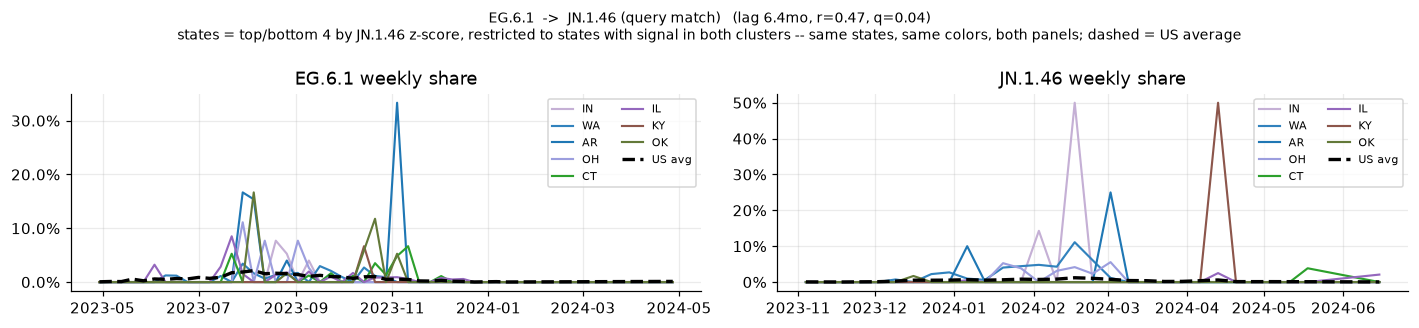

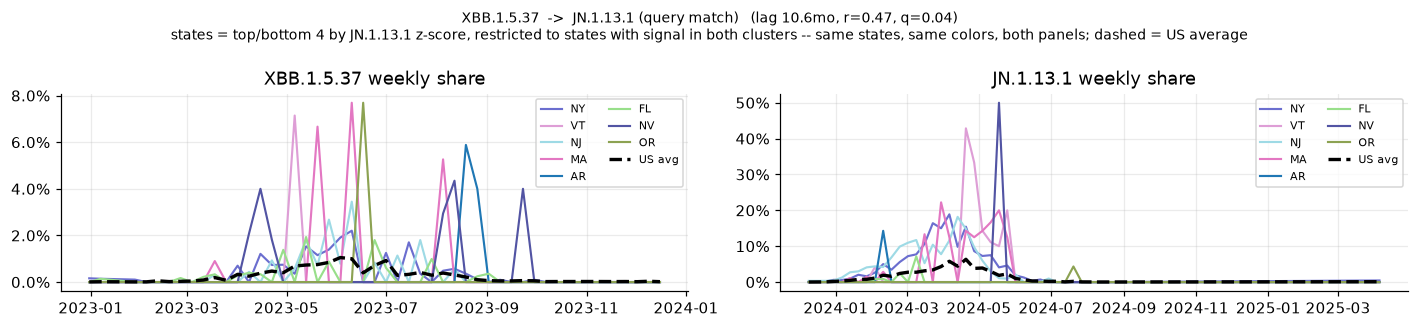

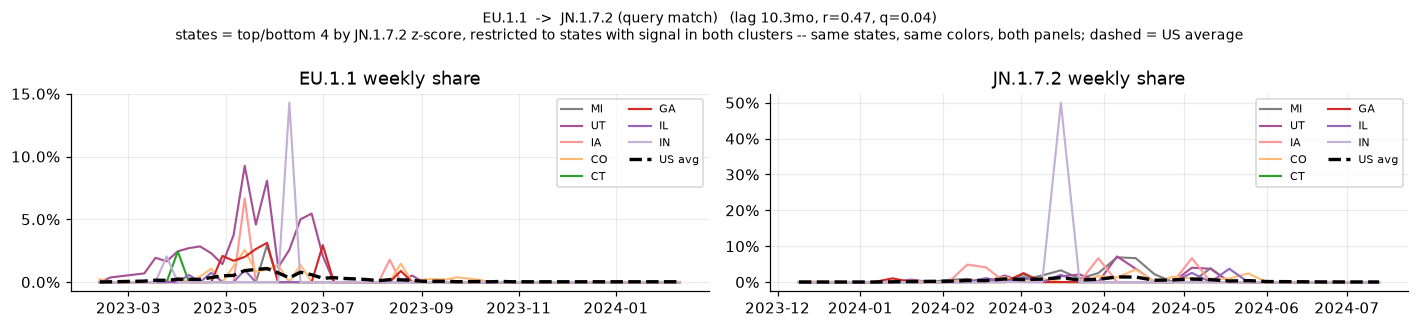

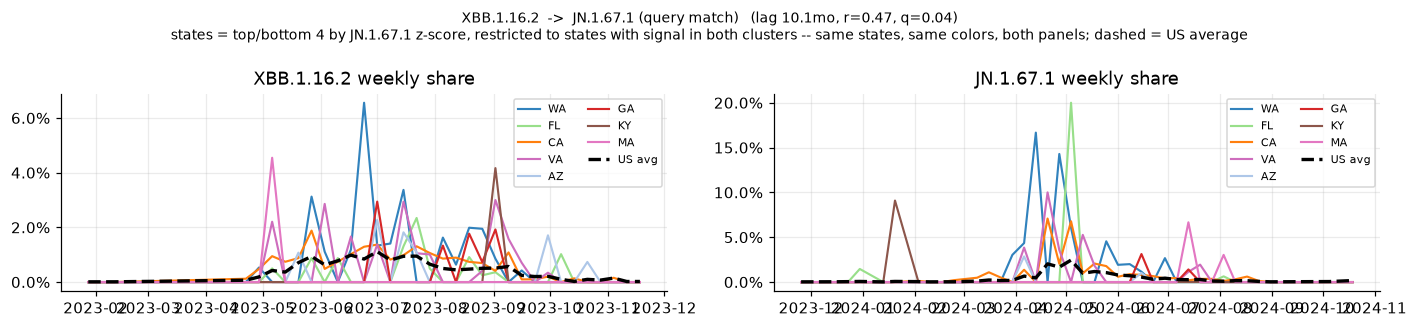

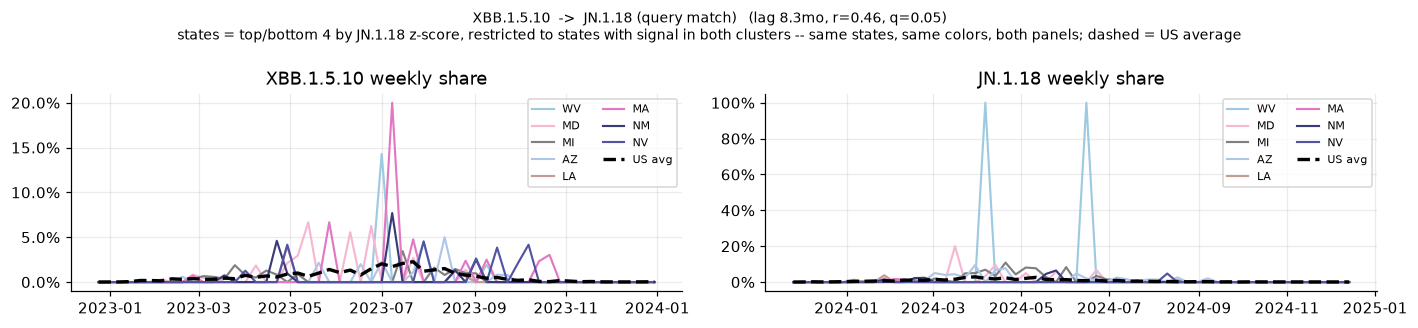

In [16]:
N_COMPARISON_STATES = 4  # per tail -- shows up to 2*N states, highest + lowest by the query cluster's z-score

def _states_with_signal(cl):
    """Geos with at least one nonzero-count week for cluster `cl` -- a state
    with no real signal for a cluster shouldn't be offered as a display
    candidate at all, since it can only ever show up as a flat line in one
    panel and be silently absent from the other."""
    sub = state_panel[(state_panel.cluster == cl) & (state_panel['count'] > 0)]
    return set(sub['geo'].unique())

for _, row in query_pairs.iterrows():
    cx, cy = row['cluster_x'], row['cluster_y']
    # Anchor the state selection on whichever side actually matches the query, not
    # always cluster_x -- when the query match is cluster_y (an earlier, unrelated
    # cluster_x drives the pairing), selecting by cluster_x's z-score picks states
    # with no particular connection to the variant being searched for. Anchoring on
    # the query match also means every pair that shares that same matched cluster
    # (there are usually several) reuses the same state roster, instead of a fresh,
    # largely-disjoint cast for every single pair.
    focus_cluster = cx if cx in matching_clusters else cy

    # Restrict candidates to states with genuine signal in *both* clusters, so
    # every state picked is guaranteed to draw a real (non-flat, non-missing)
    # line in both panels -- otherwise a state selected purely on cluster X's
    # z-score can turn out to have zero recorded cluster-Y sequences ever, and
    # silently vanish from the right-hand legend instead of appearing there.
    common_states = _states_with_signal(cx) & _states_with_signal(cy)
    z_focus = (relative_level[(relative_level.cluster == focus_cluster) & (relative_level.geo.isin(common_states))]
               .set_index('geo')['zscore'].dropna())
    # nlargest/nsmallest already order high-to-low and low-to-high respectively,
    # so this list is ordered most-elevated -> most-depressed on focus_cluster;
    # plotting both panels from this same ordered list is what keeps the two
    # legends -- and colors, via the fixed global STATE_COLORS -- identical.
    compare_states = list(dict.fromkeys(
        z_focus.nlargest(N_COMPARISON_STATES).index.tolist() + z_focus.nsmallest(N_COMPARISON_STATES).index.tolist()
    ))

    fig, axes = plt.subplots(1, 2, figsize=(13, 3))
    for ax, cl in zip(axes, [cx, cy]):
        sub = state_panel[state_panel.cluster == cl]
        wide = sub.pivot_table(index='week_ending', columns='geo', values='share', aggfunc='sum').fillna(0)
        for g in compare_states:
            if g in wide.columns:
                ax.plot(wide.index, wide[g], label=g, color=STATE_COLORS.get(g), lw=1.4, zorder=3)
        nat = national_cluster_shares[national_cluster_shares.cluster == cl].set_index('week_ending')['share']
        ax.plot(nat.index, nat.values, color='black', lw=2.2, ls='--', label='US avg', zorder=10)
        ax.yaxis.set_major_formatter(PercentFormatter(1.0))
        ax.set_title(f'{cl} weekly share')
        ax.legend(fontsize=7, ncol=2)
    highlight = ' (query match)'
    fig.suptitle(f"{cx}{highlight if cx in matching_clusters else ''}  ->  "
                 f"{cy}{highlight if cy in matching_clusters else ''}   "
                 f'(lag {row.lag_months:.1f}mo, r={row.spearman_r:.2f}, q={row.q_value:.1g})\n'
                 f'states = top/bottom {N_COMPARISON_STATES} by {focus_cluster} z-score, restricted to states with '
                 f'signal in both clusters -- same states, same colors, both panels; dashed = US average',
                 fontsize=9)
    fig.tight_layout()
    fig.savefig(f"{RESULTS}/07_overlay_{cx.replace('.', '_')}_{cy.replace('.', '_')}.png")
    plt.show()

if query_pairs.empty:
    print(f'No FDR-significant pairs involve {VARIANT_QUERY!r} at the current clustering settings -- '
          f'try a less aggressive significance_threshold in section 3, or check whether '
          f"{VARIANT_QUERY!r} even survived as its own wave (see wave_windows).")

### 8b. The same comparison, with vaccination

Vaccination coverage is treated **as if each campaign were a variant**: it enters the state
panel with the same `(geo, cluster, week_ending, count, total_count, share)` schema, so the
wave-window, cross-state z-score and Spearman machinery from sections 5-7 applies unchanged.
`count` is people covered and `total_count` the pooling-weight population, so pooling a weak
state into its Census division is a plain sum on both and yields correctly population-weighted
regional coverage.

**Observed sources only.** The SMH scenario coverage curves used earlier have been dropped:
round 14's fall-2022 curve was derived from *2020-21 flu vaccine* coverage (rescaled and
discounted for fatigue), and rounds 17/18 are season schedules fed into models. Neither is a
measurement. What remains are four measured series, **each covering all 50 states + DC**:

| Campaign | Window | Collection | Base |
|---|---|---|---|
| `primary series (CDC admin)` | 2020-12 → 2022-06 | **Administrative** dose counts | total population |
| `vaccinated >=1 dose (Delphi CTIS)` | 2021-01 → **2022-06-25** | Self-reported survey | adults |
| `vaccinated >=1 dose (NIS-ACM)` | 2021-04 → 2023-06 | Self-reported survey | adults 18+ |
| `bivalent booster (NIS-ACM)` | 2022-08 → 2023-06 | Self-reported survey | adults who completed primary series |

**What covers the 2022-10 → 2023-10 window:** only **NIS-ACM**. Delphi's CTIS was
discontinued on 2022-06-25 — every `fb-survey` signal is inactive after that date — so it
cannot reach the bivalent period at all; it is the deep-history source instead, covering the
Alpha/Delta/Omicron BA.1/BA.2 waves. NIS-ACM's bivalent series runs 2022-08 → 2023-06, which
leaves Jul-Oct 2023 uncovered; that is largely a genuine inter-campaign lull (bivalent uptake
had plateaued by ~Feb 2023 and the updated 2023-24 vaccine was not recommended until Sept
2023) rather than missing data.

Note also that the CDC **NIS-CCM** child module is published as national estimates only — a
single geography — so it cannot support a state-level design. NIS-**ACM** (adult) is the
jurisdictional counterpart used here.

**Two caveats when reading the numbers.** Self-report inflates the level: Delphi reaches ~83%
national ≥1 dose and NIS-ACM ~88%, against ~66% administrative — so compare *between-state*
patterns rather than levels. And the bivalent series' base is adults who completed the primary
series, not all adults, unlike the others.

Since coverage is cumulative and monotone, half-max peak detection is meaningless here (the
"peak" would always be the last week), so each campaign's window is its **uptake ramp** (1% to
95% of its eventual level) and `peak_week` is the week of maximum *weekly increment* -- peak
vaccination rate, the campaign's centre of mass in time, which is the right anchor for any lag
comparison. See `data/vaccination/SOURCES.md`.

,first_week,last_week,n_states,n_weeks,window_start,window_end,national_final_coverage
campaign,,,,,,,
VAX:primary series (CDC admin),2020-12-19,2022-06-04,51,77,2021-01-16,2022-01-08,0.662565
VAX:vaccinated >=1 dose (Delphi CTIS),2021-01-09,2022-06-25,51,77,2021-01-09,2021-05-29,0.830881
VAX:vaccinated >=1 dose (NIS-ACM),2021-05-15,2023-06-17,51,110,2021-05-15,2022-01-15,0.877875
VAX:bivalent booster (NIS-ACM),2022-10-15,2023-06-17,51,36,2022-10-15,2023-01-14,0.345176


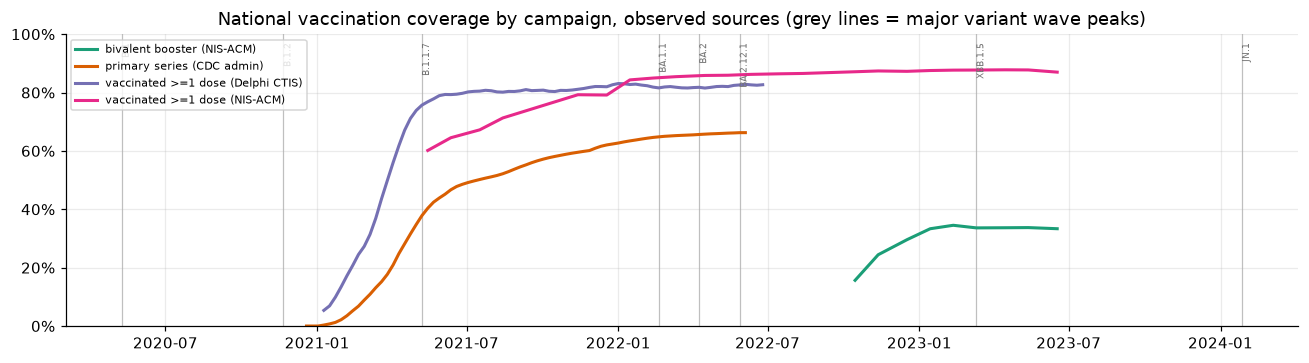

In [17]:
vax_long = vw.load_vaccination_campaigns()
vax_windows = vw.vaccination_campaign_windows(vax_long)

summary = (vax_long.groupby('campaign')
           .agg(first_week=('week_ending', 'min'), last_week=('week_ending', 'max'),
                n_states=('state', 'nunique'), n_weeks=('week_ending', 'nunique'))
           .join(vax_windows.set_index('cluster')[['window_start', 'window_end', 'peak_share']])
           .sort_values('first_week'))
summary = summary.rename(columns={'peak_share': 'national_final_coverage'})
display(summary)

# National coverage per campaign, with the variant wave peaks marked for timing context.
nat_vax = vax_long.groupby(['campaign', 'week_ending'])[['covered', 'denominator']].sum()
nat_vax['coverage'] = nat_vax.covered / nat_vax.denominator

fig, ax = plt.subplots(figsize=(12, 3.4))
vax_palette = plt.get_cmap('Dark2')
VAX_COLORS = {}
for i, (campaign, s) in enumerate(nat_vax.groupby(level='campaign')['coverage']):
    s = s.droplevel(0).sort_index()
    VAX_COLORS[campaign] = vax_palette(i % 8)
    ax.plot(s.index, s.values, lw=2, color=VAX_COLORS[campaign],
            label=campaign.replace(vw.VAX_PREFIX, ''))
for cl in wave_windows.sort_values('peak_share', ascending=False).head(8)['cluster']:
    w = wave_windows.set_index('cluster').loc[cl]
    ax.axvline(w['peak_week'], color='0.75', lw=0.8, zorder=0)
    ax.text(w['peak_week'], 0.97, f' {cl}', rotation=90, fontsize=6, va='top', color='0.45')
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_ylim(0, 1)
ax.set_title('National vaccination coverage by campaign, observed sources (grey lines = major variant wave peaks)')
ax.legend(fontsize=7, loc='upper left')
fig.tight_layout()
fig.savefig(f'{RESULTS}/10_vaccination_campaigns.png')
plt.show()

In [18]:
# Same weak-state handling as the variant panel, so geo labels line up when the
# two are concatenated (`weak` comes from section 4's volume classification).
vax_panel = vw.build_vaccination_panel(vax_long, weak_states=weak, mode='pool')
print(f'vax panel: {vax_panel.geo.nunique()} geos vs {state_panel.geo.nunique()} in the variant panel; '
      f'{sorted(set(vax_panel.geo) ^ set(state_panel.geo)) or "identical geo sets"}')

# Treat each campaign exactly like a variant cluster: same wave-window -> mean
# share -> cross-state z-score path used in section 6.
vax_relative_level = vw.relative_level_zscore(vax_panel, vax_windows)
relative_level_all = pd.concat([relative_level, vax_relative_level], ignore_index=True)
panel_all = pd.concat([state_panel, vax_panel], ignore_index=True)

# Correlate every campaign against every variant cluster appearing in the query
# pairs, reporting the peak-to-peak gap so the timing is explicit.
variant_clusters = pd.unique(query_pairs[['cluster_x', 'cluster_y']].values.ravel())
ww_all = pd.concat([wave_windows, vax_windows], ignore_index=True).set_index('cluster')

rows = []
for campaign in vax_windows['cluster']:
    for cl in variant_clusters:
        r, p, n = vw.pairwise_spearman(relative_level_all, campaign, cl)
        gap_days = (ww_all.loc[cl, 'peak_week'] - ww_all.loc[campaign, 'peak_week']).days
        rows.append({'campaign': campaign.replace(vw.VAX_PREFIX, ''), 'variant': cl,
                     'lag_months_vax_to_variant': gap_days / 30.44,
                     'n_states': n, 'spearman_r': r, 'p_value': p})
vax_corr = vw.add_fdr_correction(pd.DataFrame(rows))
vax_corr['in_6_12mo_band'] = vax_corr.lag_months_vax_to_variant.between(6, 12)
display(vax_corr.reindex(vax_corr.spearman_r.abs().sort_values(ascending=False).index).head(20))

vax panel: 43 geos vs 43 in the variant panel; identical geo sets


,campaign,variant,lag_months_vax_to_variant,n_states,spearman_r,p_value,q_value,fdr_significant,in_6_12mo_band
104,vaccinated >=1 dose (NIS-ACM),JN.1.47,24.605782,43,0.507616,0.000512,0.057319,False,False
9,bivalent booster (NIS-ACM),JN.1.16,18.396846,43,0.443263,0.002911,0.150090,False,False
87,vaccinated >=1 dose (NIS-ACM),JN.1.13.1,27.825230,43,0.401565,0.007607,0.150090,False,False
15,bivalent booster (NIS-ACM),JN.1.4.5,15.177398,43,0.400997,0.007701,0.150090,False,False
48,primary series (CDC admin),JN.1.47,33.114323,43,0.398697,0.008092,0.150090,False,False
31,primary series (CDC admin),JN.1.13.1,36.333771,43,0.395441,0.008675,0.150090,False,False
38,primary series (CDC admin),XBB.1.5,22.996058,43,0.387496,0.010250,0.150090,False,False
37,primary series (CDC admin),JN.1.16,37.023653,43,0.380865,0.011746,0.150090,False,False
99,vaccinated >=1 dose (NIS-ACM),JN.1.4.5,25.295664,43,0.369582,0.014722,0.150090,False,False
94,vaccinated >=1 dose (NIS-ACM),XBB.1.5,14.487516,43,0.367865,0.015227,0.150090,False,False


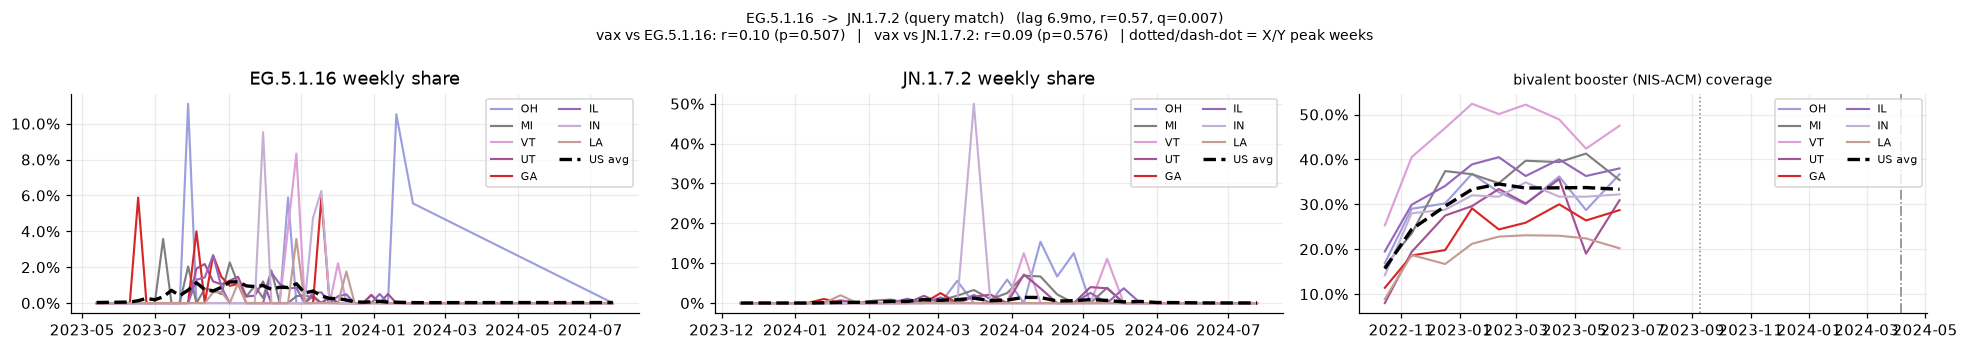

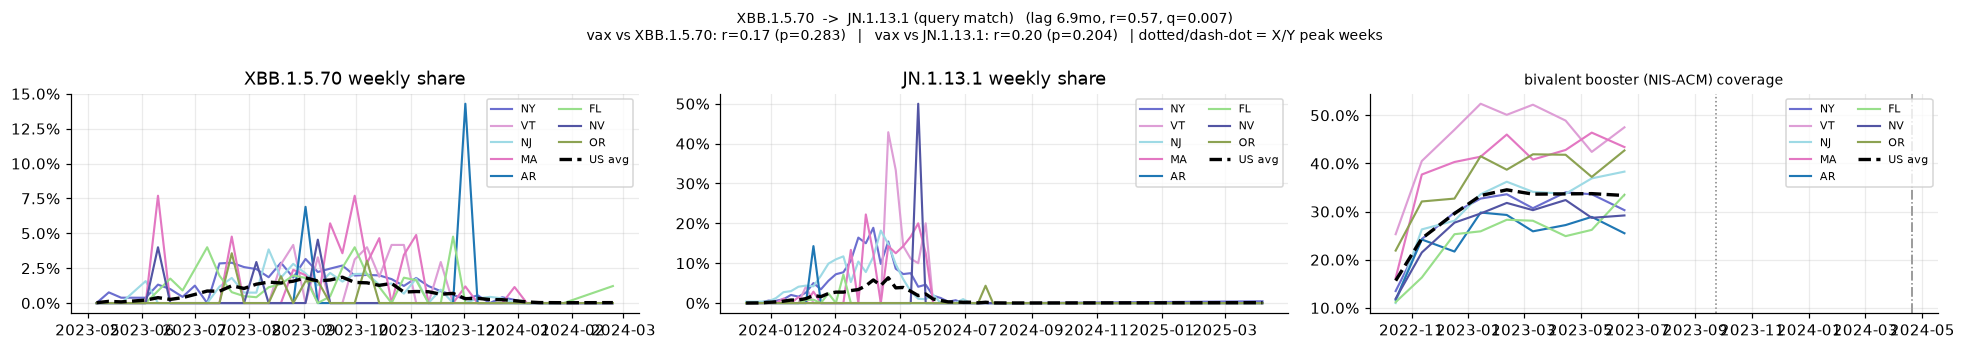

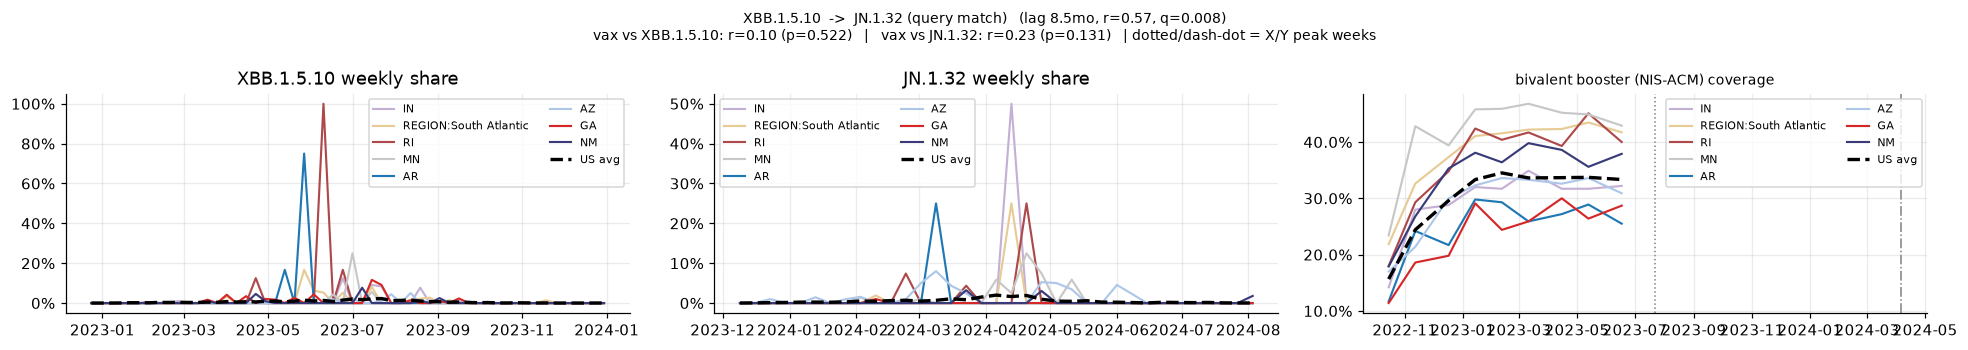

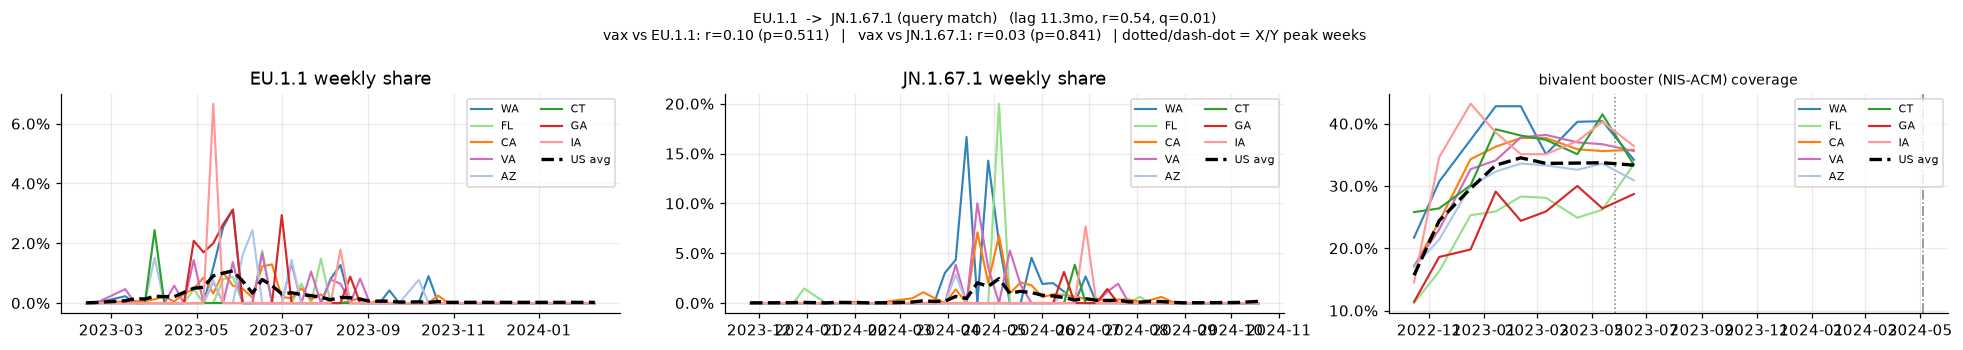

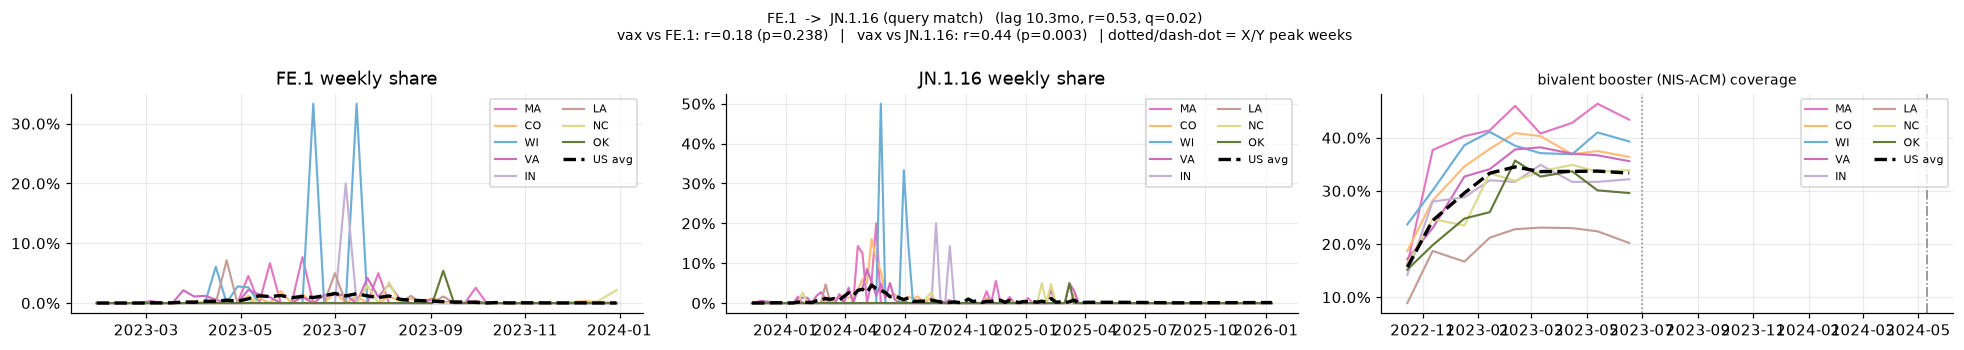

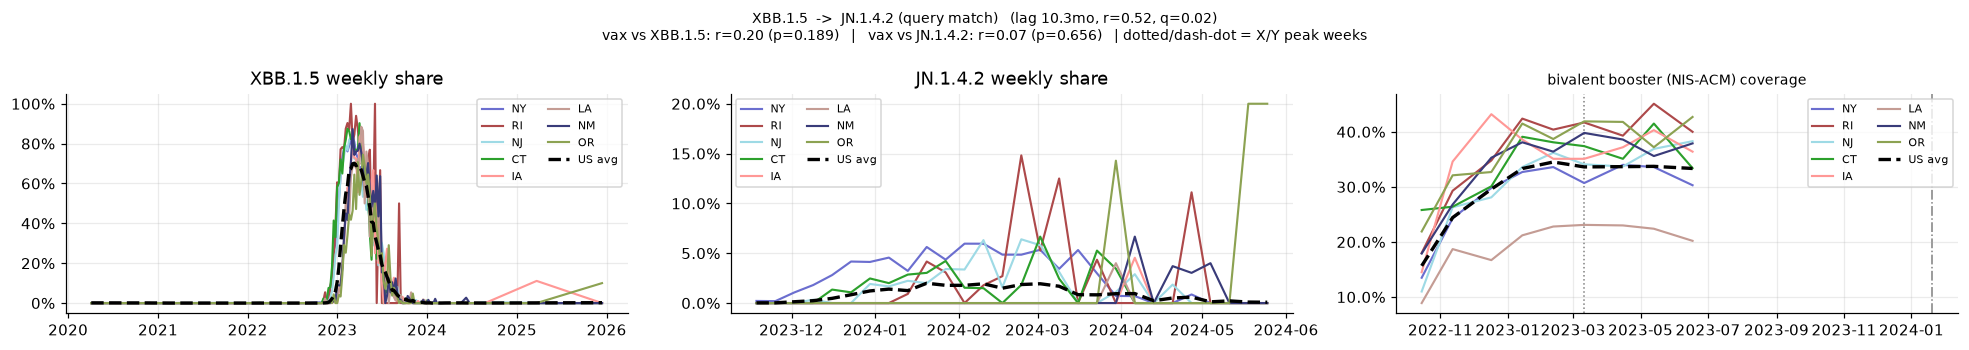

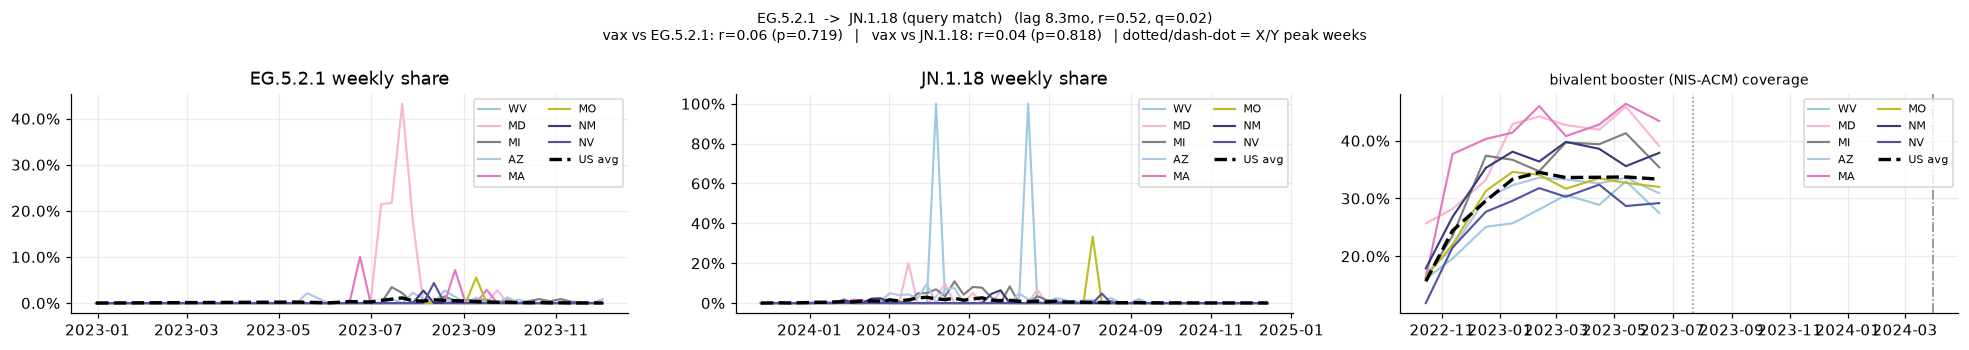

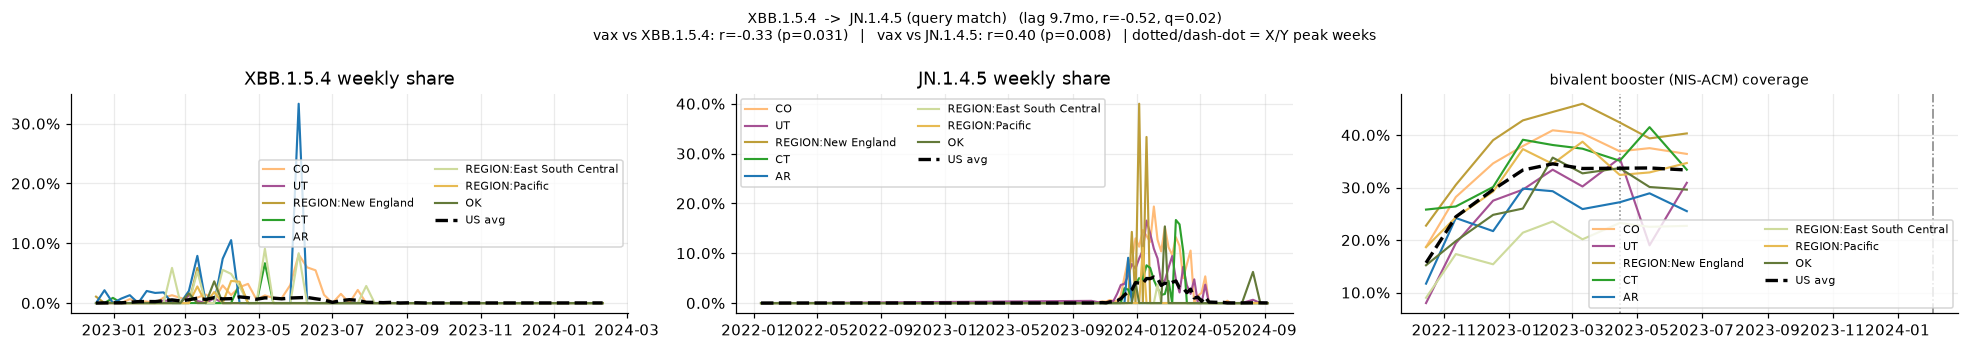

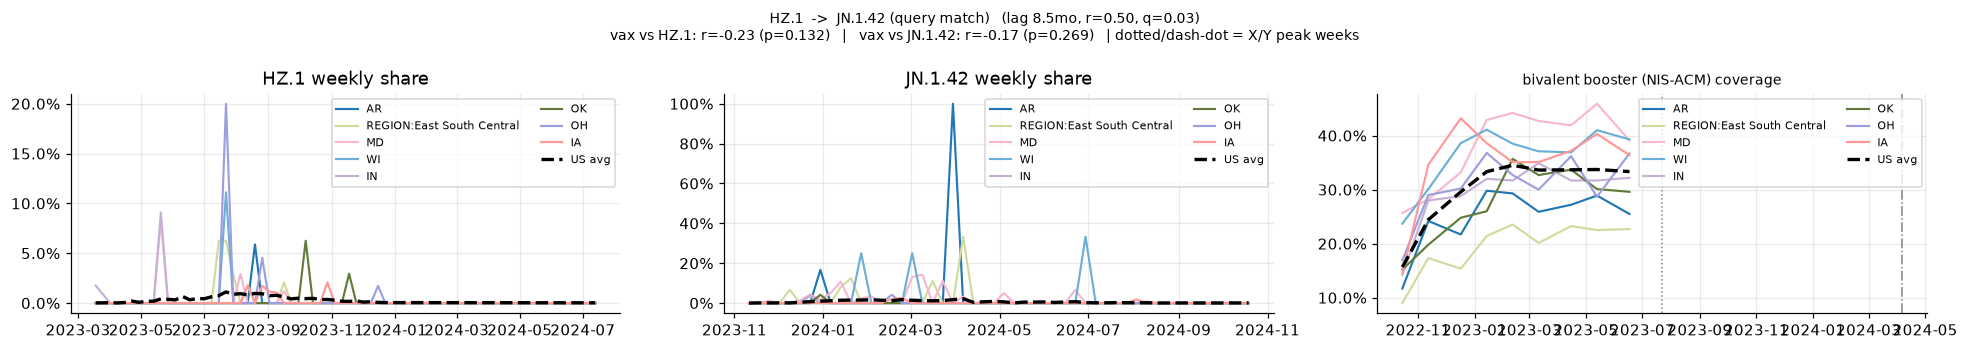

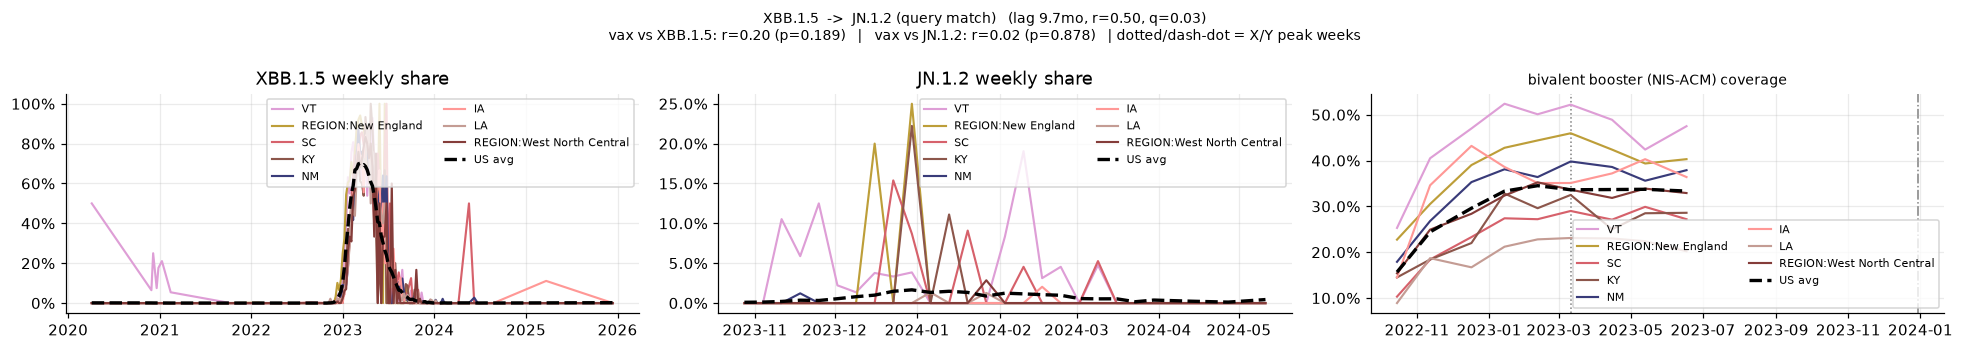

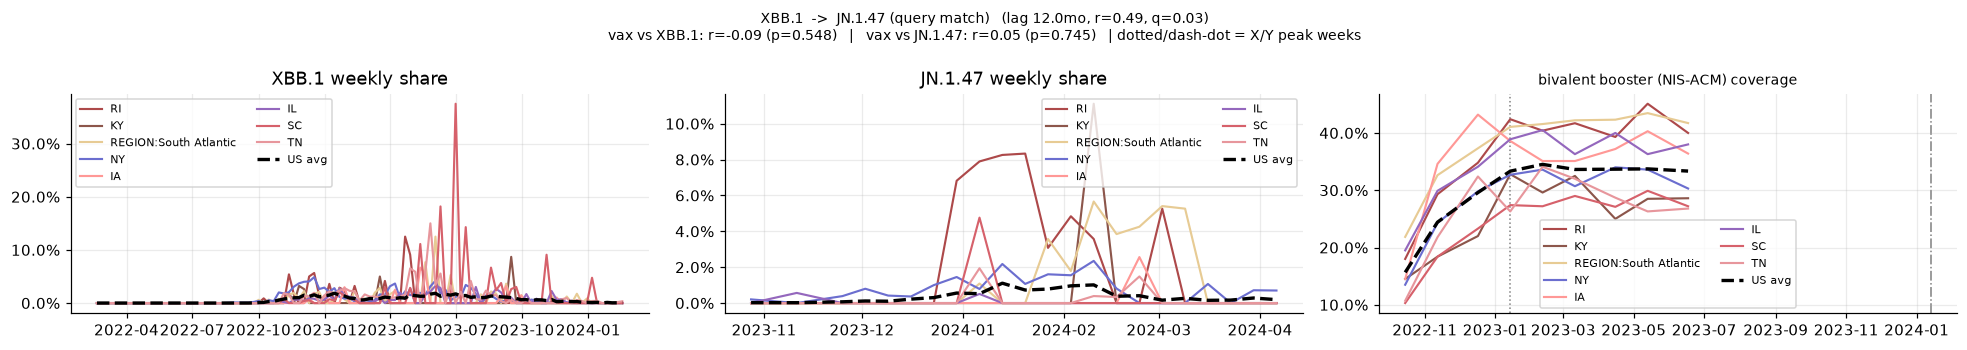

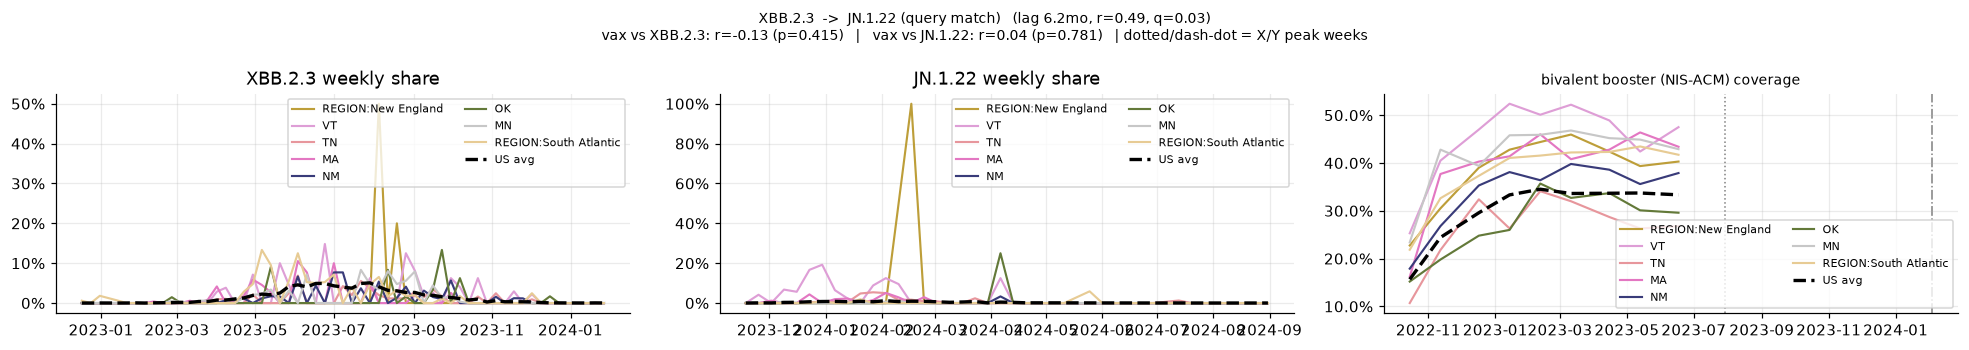

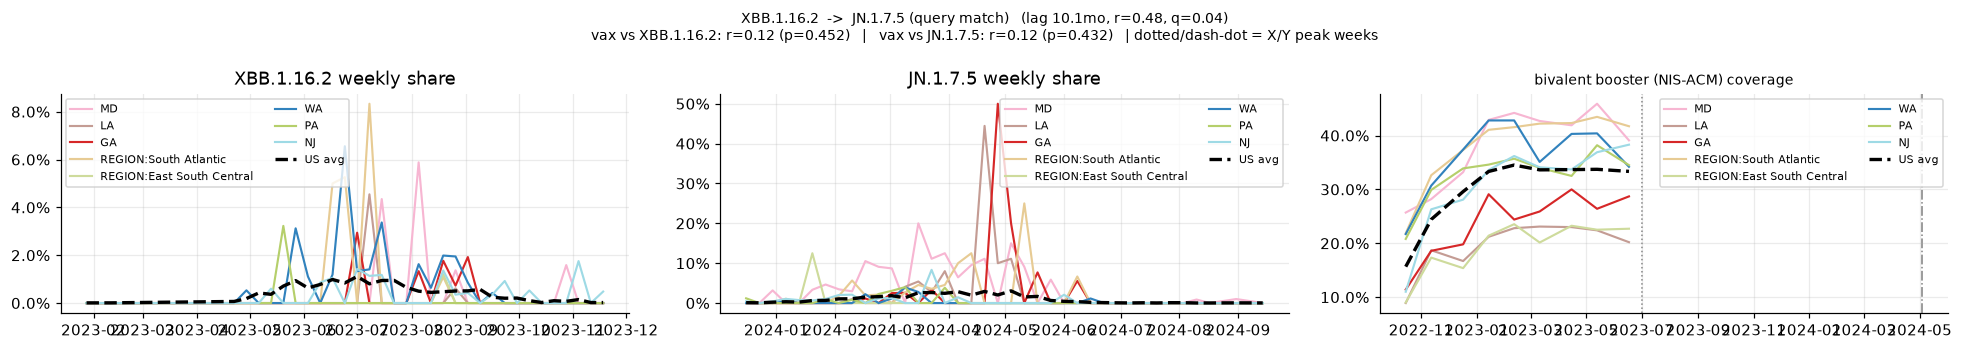

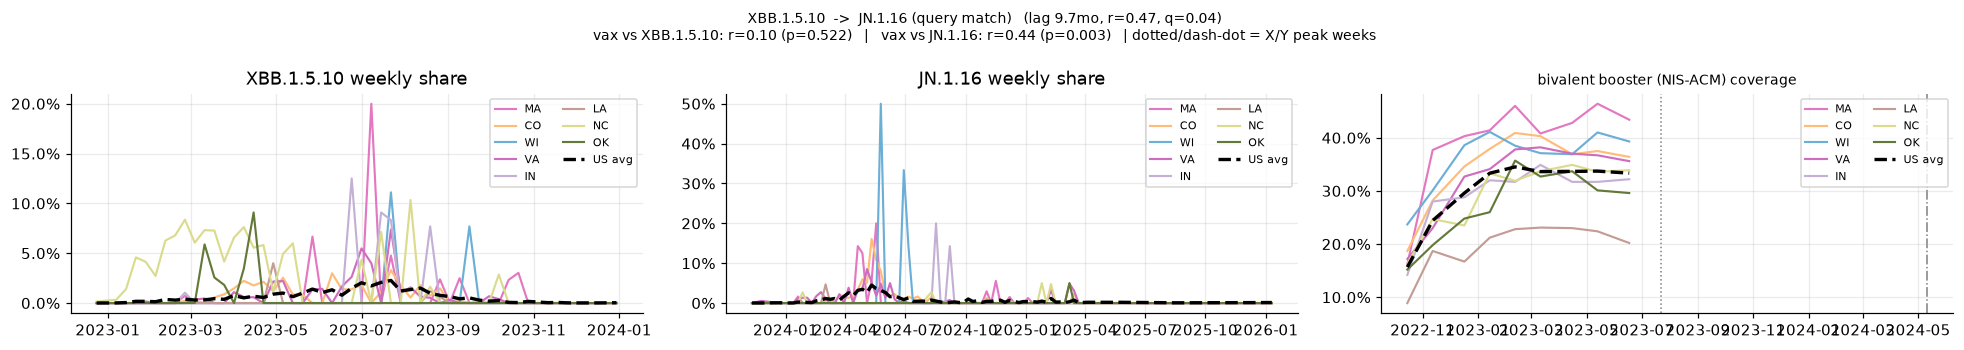

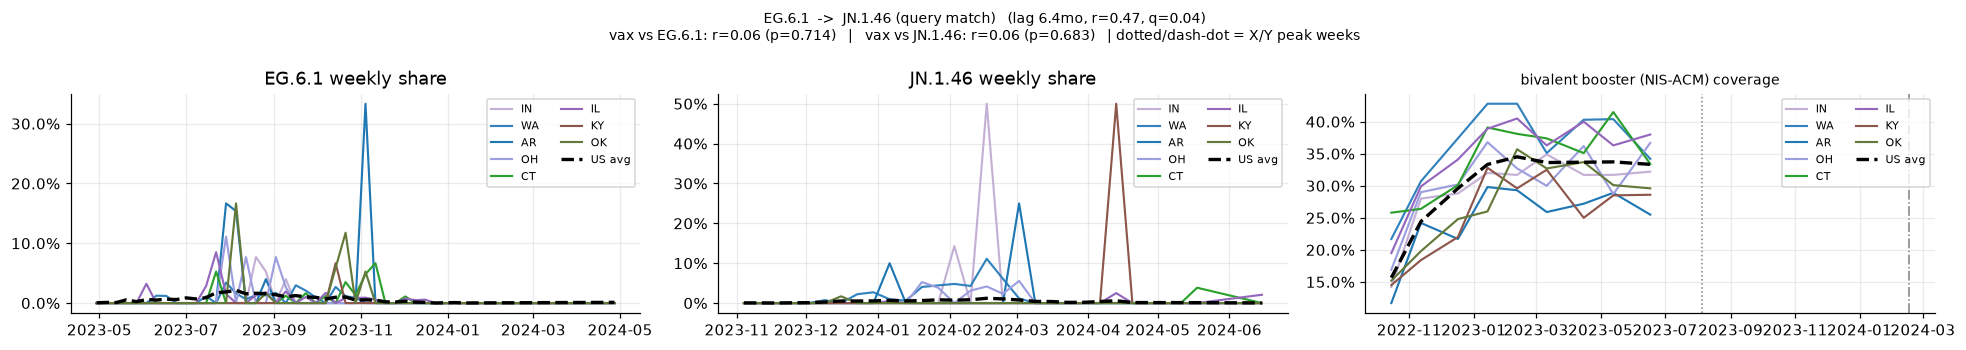

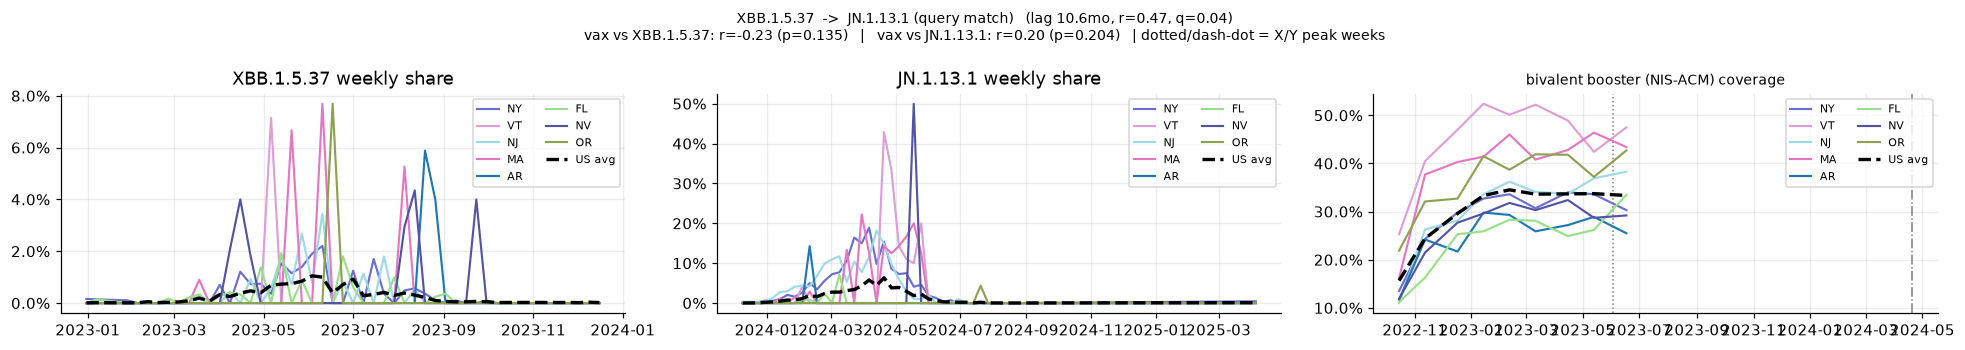

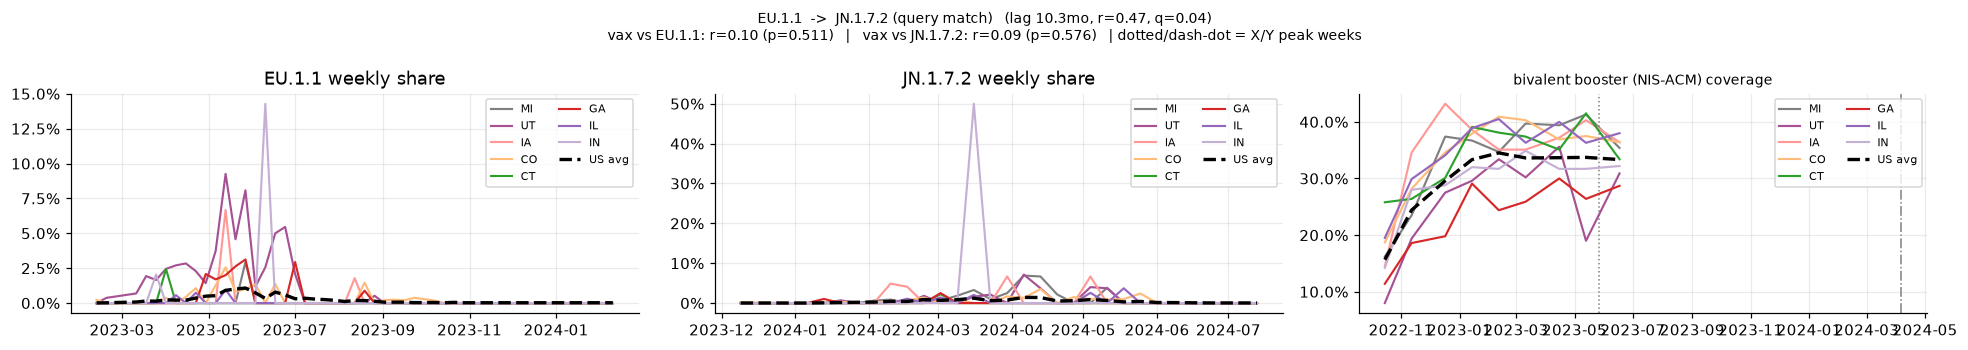

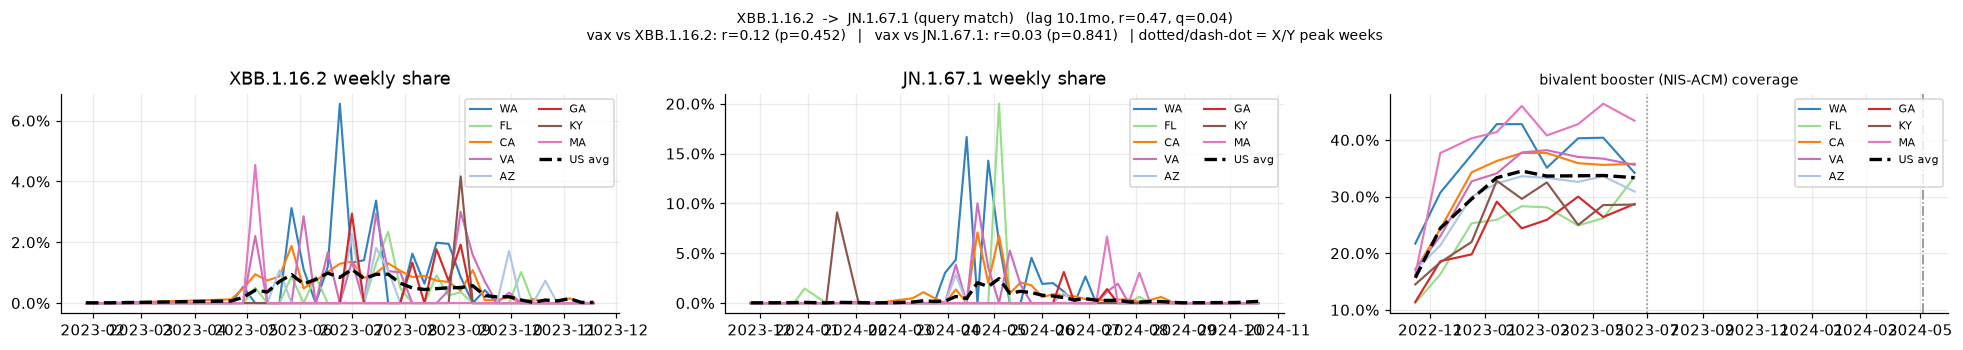

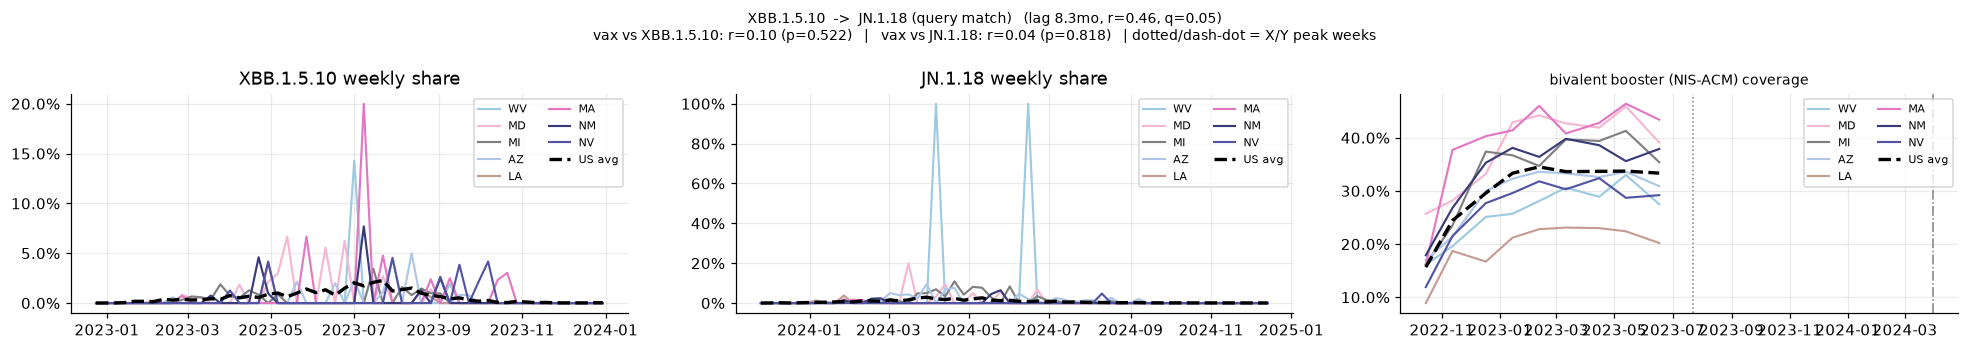

In [19]:
# The "with vaccination" version of the section-8 overlay: a third panel carrying
# the vaccination campaign whose uptake ramp sits closest to the middle of the
# X -> Y interval, i.e. the campaign that actually ran *between* the two waves.
def _nearest_campaign(peak_x, peak_y):
    midpoint = peak_x + (peak_y - peak_x) / 2
    gaps = (vax_windows.set_index('cluster')['peak_week'] - midpoint).abs()
    return gaps.idxmin()

for _, row in query_pairs.iterrows():
    cx, cy = row['cluster_x'], row['cluster_y']
    focus_cluster = cx if cx in matching_clusters else cy
    campaign = _nearest_campaign(ww_all.loc[cx, 'peak_week'], ww_all.loc[cy, 'peak_week'])

    common_states = _states_with_signal(cx) & _states_with_signal(cy) & set(vax_panel.geo)
    z_focus = (relative_level[(relative_level.cluster == focus_cluster) & (relative_level.geo.isin(common_states))]
               .set_index('geo')['zscore'].dropna())
    compare_states = list(dict.fromkeys(
        z_focus.nlargest(N_COMPARISON_STATES).index.tolist() + z_focus.nsmallest(N_COMPARISON_STATES).index.tolist()
    ))

    fig, axes = plt.subplots(1, 3, figsize=(18, 3.2))
    for ax, cl in zip(axes[:2], [cx, cy]):
        sub = state_panel[state_panel.cluster == cl]
        wide = sub.pivot_table(index='week_ending', columns='geo', values='share', aggfunc='sum').fillna(0)
        for g in compare_states:
            if g in wide.columns:
                ax.plot(wide.index, wide[g], label=g, color=STATE_COLORS.get(g), lw=1.4, zorder=3)
        nat = national_cluster_shares[national_cluster_shares.cluster == cl].set_index('week_ending')['share']
        ax.plot(nat.index, nat.values, color='black', lw=2.2, ls='--', label='US avg', zorder=10)
        ax.yaxis.set_major_formatter(PercentFormatter(1.0))
        ax.set_title(f'{cl} weekly share')
        ax.legend(fontsize=7, ncol=2)

    # Third panel: vaccination coverage, same states, same colors.
    ax = axes[2]
    vsub = vax_panel[vax_panel.cluster == campaign]
    vwide = vsub.pivot_table(index='week_ending', columns='geo', values='share', aggfunc='sum')
    for g in compare_states:
        if g in vwide.columns:
            ax.plot(vwide.index, vwide[g], label=g, color=STATE_COLORS.get(g), lw=1.4, zorder=3)
    vnat = (vax_long[vax_long.campaign == campaign].groupby('week_ending')[['covered', 'denominator']].sum())
    ax.plot(vnat.index, vnat.covered / vnat.denominator, color='black', lw=2.2, ls='--',
            label='US avg', zorder=10)
    for cl, style in ((cx, ':'), (cy, '-.')):
        ax.axvline(ww_all.loc[cl, 'peak_week'], color='0.5', lw=1.0, ls=style, zorder=1)
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.set_title(f"{campaign.replace(vw.VAX_PREFIX, '')} coverage", fontsize=9)
    ax.legend(fontsize=7, ncol=2)

    r_vx, p_vx, _ = vw.pairwise_spearman(relative_level_all, campaign, cx)
    r_vy, p_vy, _ = vw.pairwise_spearman(relative_level_all, campaign, cy)
    highlight = ' (query match)'
    fig.suptitle(f"{cx}{highlight if cx in matching_clusters else ''}  ->  "
                 f"{cy}{highlight if cy in matching_clusters else ''}   "
                 f'(lag {row.lag_months:.1f}mo, r={row.spearman_r:.2f}, q={row.q_value:.1g})\n'
                 f'vax vs {cx}: r={r_vx:.2f} (p={p_vx:.3f})   |   vax vs {cy}: r={r_vy:.2f} (p={p_vy:.3f})   '
                 f'| dotted/dash-dot = X/Y peak weeks',
                 fontsize=9)
    fig.tight_layout()
    fig.savefig(f"{RESULTS}/11_vax_overlay_{cx.replace('.', '_')}_{cy.replace('.', '_')}.png")
    plt.show()

if query_pairs.empty:
    print('No pairs selected -- widen strings_vector or VARIANT_QUERY above.')

#### 8b-ii. Correcting self-report against administrative counts, and export

Self-reported coverage and administrative dose counts disagree, and they disagree *by
different amounts in different states* — so a single national adjustment would be the wrong
tool. Wherever a survey series overlaps an administrative series measuring the same thing on
the same base, a per-state factor is estimated as the **median weekly ratio**
`administrative / reported`, giving `reported * factor ≈ real`.

Median rather than a fitted slope, because the first weeks of a rollout have the two series
ramping with different reporting lags and would otherwise drag the estimate. CDC censors its
≥1-dose metric at 95%, so capped observations are excluded — a censored numerator would bias
every high-coverage state's factor upward.

Three details worth knowing:

* **The bases are reconciled before comparing.** NIS-ACM reports bivalent uptake *among adults
  who completed the primary series*, while CDC reports it as a share of all adults. The
  administrative figure is divided by administrative primary-series coverage to put it on
  NIS's base — both halves administrative, so no survey data leaks into the reference.
* **Not every series is inflated.** Once compared like-for-like, NIS-ACM's ≥1-dose estimate is
  essentially unbiased (factor ≈ 1.0) and Delphi runs ~9% high; it is the *bivalent* series
  that is badly inflated (factor ≈ 0.73). The much larger gap between survey ≥1-dose and
  administrative *fully-vaccinated* is mostly an apples-to-oranges comparison, not bias.
* **The 2023-24 series has no administrative overlap** (CDC stopped reporting 2023-05-10, that
  series starts 2023-09-30), so it inherits the bivalent factors. That is an assumption, and
  `correction_method` records it as inherited rather than measured.

Everything is then put on a common base — a share of the adult population — smoothed, and
exported, so the ascertainment notebook can read it without re-running any of this.

,n_states,median_factor,min_factor,max_factor,median_overlap_weeks
campaign,,,,,
VAX:bivalent booster (NIS-ACM),51,0.727,0.564,0.846,31.0
VAX:updated 2023-24 (NIS-ACM),51,0.727,0.564,0.846,NaN
VAX:vaccinated >=1 dose (Delphi CTIS),51,0.914,0.769,1.013,72.0
VAX:vaccinated >=1 dose (NIS-ACM),51,1.007,0.877,1.096,105.0


estimation method: {'measured': 153, 'inherited from bivalent booster (NIS-ACM)': 51}


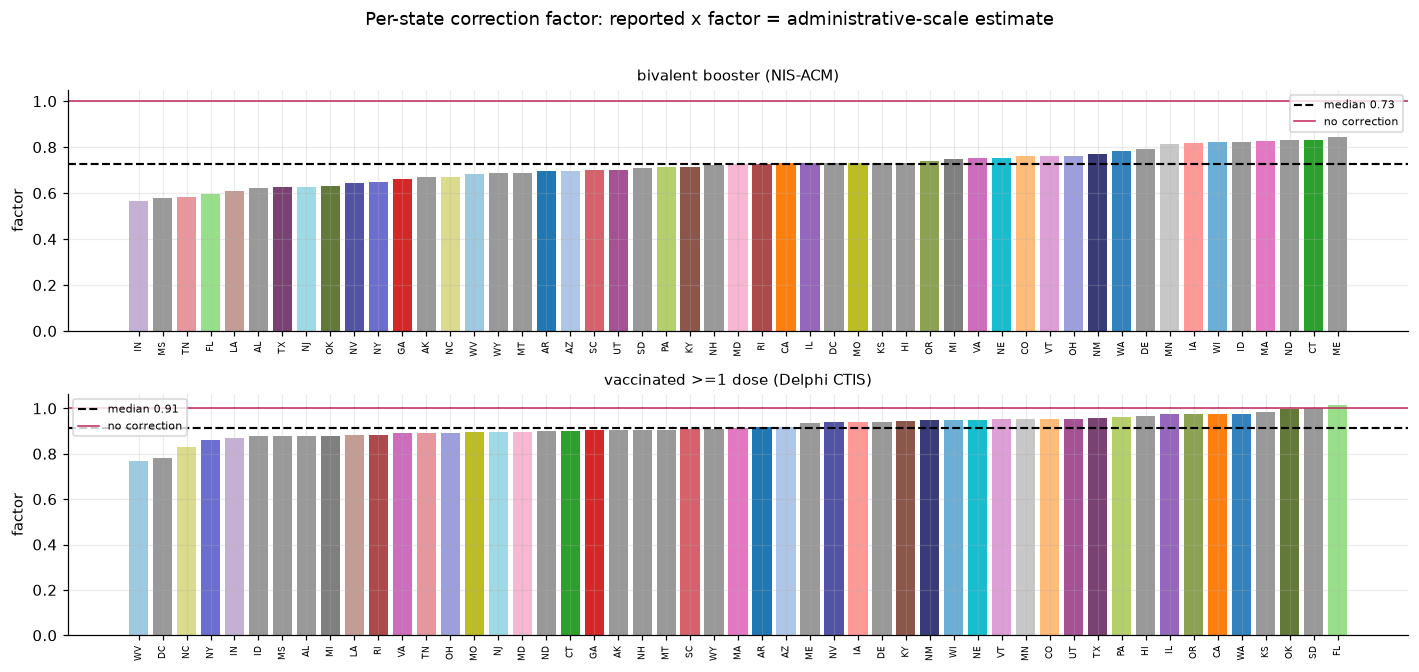

In [20]:
corrected_vax, vax_factors, vax_admin = vw.build_corrected_vaccination_series()

summary = (vax_factors.groupby('campaign')
           .agg(n_states=('state', 'nunique'), median_factor=('factor', 'median'),
                min_factor=('factor', 'min'), max_factor=('factor', 'max'),
                median_overlap_weeks=('n_weeks', 'median'))
           .round(3))
display(summary)
print('estimation method:', vax_factors.method.value_counts().to_dict())

# Per-state factors for the two measured campaigns that matter most.
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=False)
for ax, camp in zip(axes, [vw.VAX_PREFIX + 'bivalent booster (NIS-ACM)',
                           vw.VAX_PREFIX + 'vaccinated >=1 dose (Delphi CTIS)']):
    sub = vax_factors[vax_factors.campaign == camp].sort_values('factor')
    ax.bar(sub.state, sub.factor, color=[STATE_COLORS.get(s, '0.6') for s in sub.state])
    ax.axhline(sub.factor.median(), color='black', ls='--', lw=1.4,
               label=f'median {sub.factor.median():.2f}')
    ax.axhline(1.0, color=COL['pos'], lw=1, label='no correction')
    ax.set_ylabel('factor'); ax.set_title(camp.replace(vw.VAX_PREFIX, ''), fontsize=10)
    ax.tick_params(axis='x', rotation=90, labelsize=6)
    ax.legend(fontsize=7)
fig.suptitle('Per-state correction factor: reported x factor = administrative-scale estimate', y=1.01)
fig.tight_layout()
fig.savefig(f'{RESULTS}/12_vaccination_correction_factors.png', bbox_inches='tight')
plt.show()

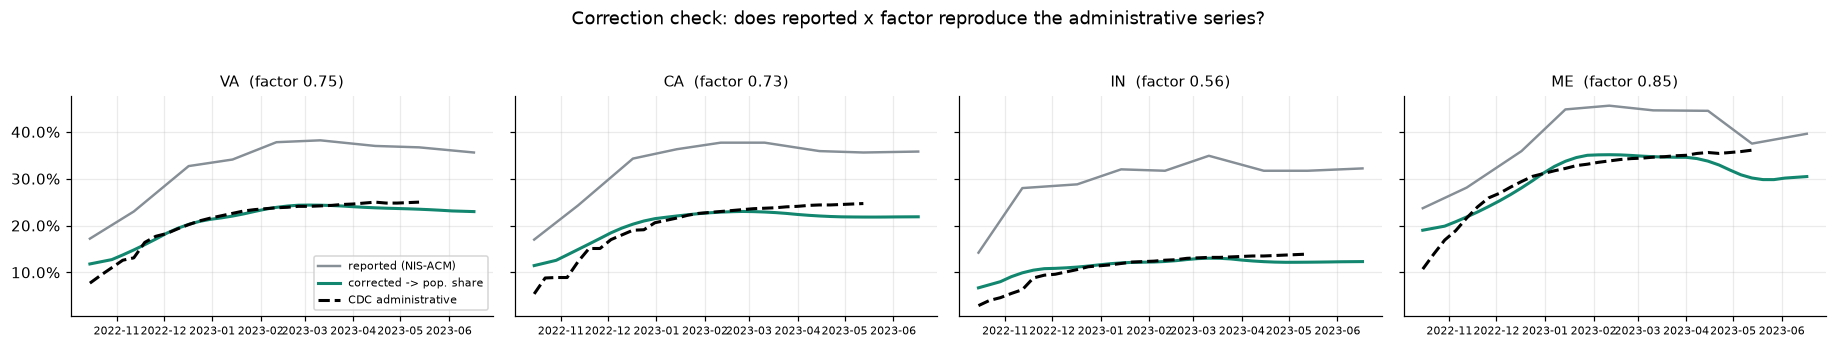

wrote /sfs/gpfs/tardis/project/bii_nssac/people/bl4zc/pgcoe_genepi_analytics/data/vaccination/vaccination_state_weekly_corrected.csv
wrote /sfs/gpfs/tardis/project/bii_nssac/people/bl4zc/pgcoe_genepi_analytics/data/vaccination/vaccination_correction_factors.csv
16,983 rows | 51 states | 5 campaigns | 2020-12-19 to 2024-05-11


In [21]:
# Does the correction actually land on the administrative series? Compare, for a
# few states, the reported bivalent share against the corrected one re-expressed
# as a share of all adults -- which is the base CDC reports on.
admin_biv = (vax_admin[vax_admin.metric == 'bivalent_among_completers']
             .merge(vax_admin[vax_admin.metric == 'series_complete_18plus']
                    [['state', 'week_ending', 'coverage']].rename(columns={'coverage': 'sc'}),
                    on=['state', 'week_ending'], how='left'))
admin_biv['admin_pop_share'] = admin_biv['coverage'] * admin_biv['sc']

check_states = ['VA', 'CA', 'IN', 'ME']
fig, axes = plt.subplots(1, len(check_states), figsize=(4.2 * len(check_states), 3), sharey=True)
biv = corrected_vax[corrected_vax.campaign == vw.VAX_PREFIX + 'bivalent booster (NIS-ACM)']
for ax, st in zip(axes, check_states):
    s = biv[biv.state == st].sort_values('week_ending')
    a = admin_biv[admin_biv.state == st].sort_values('week_ending')
    ax.plot(s.week_ending, s.coverage, color=COL['neutral'], lw=1.6, label='reported (NIS-ACM)')
    ax.plot(s.week_ending, s.population_share_smoothed, color=COL['level'], lw=2,
            label='corrected -> pop. share')
    ax.plot(a.week_ending, a.admin_pop_share, color='black', ls='--', lw=2, label='CDC administrative')
    f = s.correction_factor.iloc[0] if len(s) else float('nan')
    ax.set_title(f'{st}  (factor {f:.2f})', fontsize=10)
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.tick_params(axis='x', labelsize=7)
axes[0].legend(fontsize=7)
fig.suptitle('Correction check: does reported x factor reproduce the administrative series?', y=1.04)
fig.tight_layout()
fig.savefig(f'{RESULTS}/13_vaccination_correction_check.png', bbox_inches='tight')
plt.show()

export_path, factors_path = vw.export_vaccination_series(corrected_vax, vax_factors)
print('wrote', export_path)
print('wrote', factors_path)
print(f'{len(corrected_vax):,} rows | {corrected_vax.state.nunique()} states | '
      f'{corrected_vax.campaign.nunique()} campaigns | '
      f'{corrected_vax.week_ending.min():%Y-%m-%d} to {corrected_vax.week_ending.max():%Y-%m-%d}')

## 9. Secondary: fixed-lag sweep (robustness)

For the clusters involved in the top primary hits, force a comparison window at every lag in the 6-12 month grid rather than relying on the natural peak pairing -- shows how sensitive the primary result is to exact window placement.

1507 (pair, lag) rows over 36 clusters


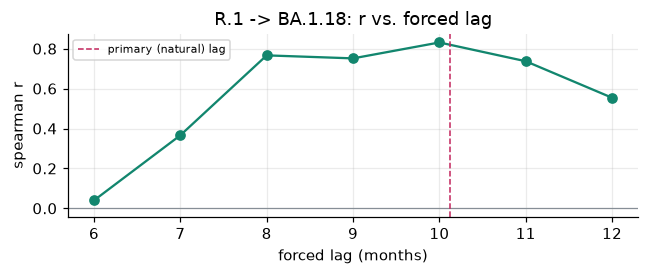

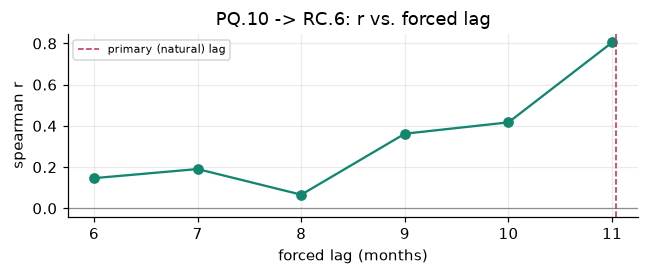

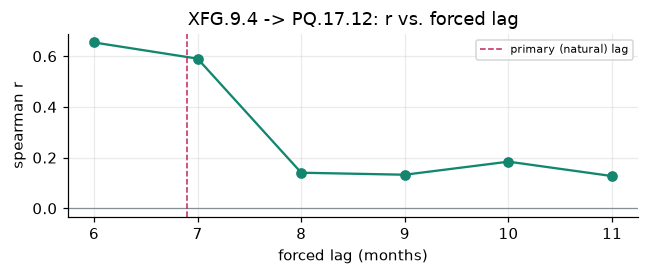

In [22]:
involved = pd.unique(top_hits[['cluster_x', 'cluster_y']].values.ravel())
sweep_windows = wave_windows[wave_windows.cluster.isin(involved)]
fixed_lag = vw.fixed_lag_correlation_table(state_panel, sweep_windows, relative_level, lag_months_grid=range(6, 13))
fixed_lag = vw.add_fdr_correction(fixed_lag)
print(f'{len(fixed_lag)} (pair, lag) rows over {len(sweep_windows)} clusters')

for _, row in top_hits.head(3).iterrows():
    cx, cy = row['cluster_x'], row['cluster_y']
    sub = fixed_lag[(fixed_lag.cluster_x == cx) & (fixed_lag.cluster_y == cy)].sort_values('lag_months')
    if sub.empty:
        continue
    fig, ax = plt.subplots(figsize=(6, 2.6))
    ax.plot(sub.lag_months, sub.spearman_r, marker='o', color=COL['level'])
    ax.axhline(0, color=COL['neutral'], lw=0.8)
    ax.axvline(row.lag_months, color=COL['pos'], ls='--', lw=1, label='primary (natural) lag')
    ax.set_xlabel('forced lag (months)'); ax.set_ylabel('spearman r')
    ax.set_title(f'{cx} -> {cy}: r vs. forced lag')
    ax.legend(fontsize=7)
    fig.tight_layout()
    plt.show()

## 10. Confound robustness

A state that's simply an early/late adopter of *every* wave would create positive correlations across nearly all pairs, not just biologically meaningful ones. Two checks on the top hits: (a) partial correlation controlling for each state's average wave-timing rank, (b) a null built by permuting states' Y-values within their own Census division.

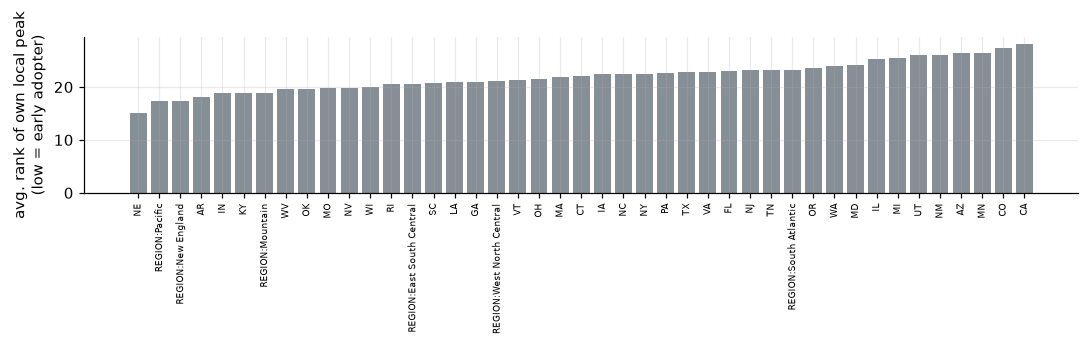

In [23]:
timing_rank = vw.state_timing_rank(state_panel, wave_windows)
fig, ax = plt.subplots(figsize=(10, 3))
tr_sorted = timing_rank.sort_values()
ax.bar(tr_sorted.index, tr_sorted.values, color=COL['neutral'])
ax.set_ylabel('avg. rank of own local peak\n(low = early adopter)')
ax.tick_params(axis='x', rotation=90, labelsize=6)
fig.tight_layout()
fig.savefig(f'{RESULTS}/08_timing_rank.png')
plt.show()

In [24]:
confound_table = vw.add_partial_correlation(top_hits.copy(), relative_level, timing_rank)
display(confound_table[['cluster_x', 'cluster_y', 'lag_months', 'spearman_r', 'q_value', 'partial_r', 'partial_p']])

,cluster_x,cluster_y,lag_months,spearman_r,q_value,partial_r,partial_p
10190,R.1,BA.1.18,10.118265,0.812199,5.280379e-07,0.812767,6.273826e-11
9771,PQ.10,RC.6,11.038108,0.804688,5.464588e-07,0.793827,3.571310e-10
13618,XFG.9.4,PQ.17.12,6.898817,0.773304,5.597719e-06,0.735727,2.842984e-08
13543,XFG.9.1,RV.1,7.358739,0.755015,1.702738e-05,0.705545,1.808872e-07
13764,XFP,RF.4,11.038108,0.741812,3.060878e-05,0.709526,1.436133e-07
289,AY.14,BA.5.5,11.957950,-0.740109,3.060878e-05,-0.694097,3.441214e-07
13519,XFG.8.1,XFG.1.1,6.438896,0.738764,3.060878e-05,0.604474,2.241328e-05
822,B.1.1.7,BA.1,7.588699,-0.733766,3.746682e-05,-0.737270,2.569225e-08
8107,MC.16,XFG.5.1.4,10.808147,0.731569,3.851106e-05,0.494089,8.824149e-04
1962,BA.2.3,BQ.1.1.32,8.968463,0.723950,5.674257e-05,0.720320,7.532761e-08


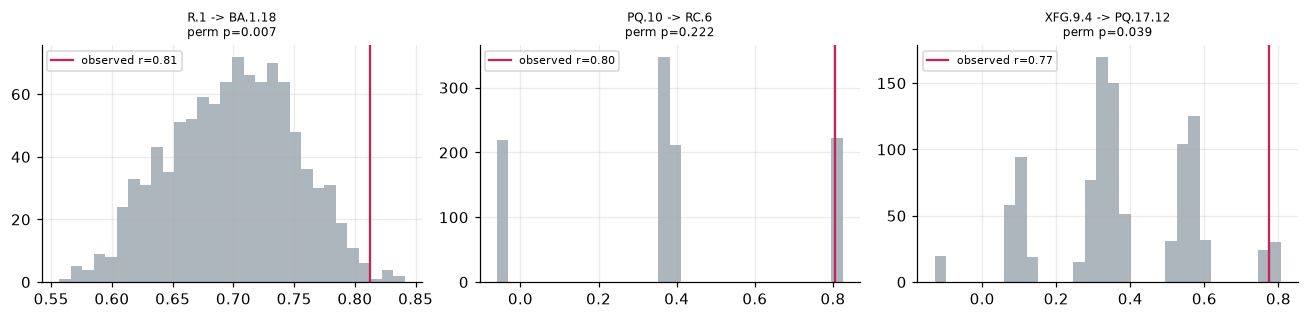

,cluster_x,cluster_y,observed_r,permutation_p
0,R.1,BA.1.18,0.812199,0.007
1,PQ.10,RC.6,0.804688,0.222
2,XFG.9.4,PQ.17.12,0.773304,0.039


In [25]:
fig, axes = plt.subplots(1, min(3, len(top_hits)), figsize=(4 * min(3, len(top_hits)), 3), squeeze=False)
perm_results = []
for i, (_, row) in enumerate(top_hits.head(3).iterrows()):
    cx, cy = row['cluster_x'], row['cluster_y']
    null_rs = vw.circular_permutation_null(relative_level, cx, cy, n_permutations=1000, seed=i)
    p_perm = vw.null_calibrated_pvalue(row['spearman_r'], null_rs)
    perm_results.append({'cluster_x': cx, 'cluster_y': cy, 'observed_r': row['spearman_r'], 'permutation_p': p_perm})
    ax = axes[0][i]
    ax.hist(null_rs, bins=30, color=COL['null'])
    ax.axvline(row['spearman_r'], color=COL['pos'], lw=1.5, label=f"observed r={row['spearman_r']:.2f}")
    ax.set_title(f'{cx} -> {cy}\nperm p={p_perm:.3f}', fontsize=8)
    ax.legend(fontsize=7)
fig.tight_layout()
fig.savefig(f'{RESULTS}/09_permutation_nulls.png')
plt.show()
perm_df = pd.DataFrame(perm_results)
display(perm_df)

## Wrap-up

Pairs that survive FDR correction *and* the partial-correlation and permutation-null confound checks -- the strongest candidates for a real cross-variant, cross-state signal at these clustering settings.

In [26]:
summary = confound_table.merge(perm_df, on=['cluster_x', 'cluster_y'], how='left')
survives = summary[(summary.fdr_significant) & (summary.partial_p < 0.05) & (summary.permutation_p < 0.05)]
print(f'{len(survives)} of {len(summary)} top hits survive FDR + partial correlation + permutation null')
display(summary[['cluster_x', 'cluster_y', 'lag_months', 'spearman_r', 'q_value', 'partial_r', 'partial_p', 'permutation_p']])

print()
print('Caveats:')
print(f'- significance_threshold={vw.DEFAULT_SIGNIFICANCE_THRESHOLD}, max_climbs={vw.MAX_CLIMBS}, '
      f'weak_state_mode={weak_state_report["mode"]!r} -- section 3/4 show how results shift under other settings.')
print('- Ecological correlations across ~40-50 units are inherently noisy; treat this as hypothesis-generating, not confirmatory.')

2 of 20 top hits survive FDR + partial correlation + permutation null


,cluster_x,cluster_y,lag_months,spearman_r,q_value,partial_r,partial_p,permutation_p
0,R.1,BA.1.18,10.118265,0.812199,5.280379e-07,0.812767,6.273826e-11,0.007
1,PQ.10,RC.6,11.038108,0.804688,5.464588e-07,0.793827,3.571310e-10,0.222
2,XFG.9.4,PQ.17.12,6.898817,0.773304,5.597719e-06,0.735727,2.842984e-08,0.039
3,XFG.9.1,RV.1,7.358739,0.755015,1.702738e-05,0.705545,1.808872e-07,NaN
4,XFP,RF.4,11.038108,0.741812,3.060878e-05,0.709526,1.436133e-07,NaN
5,AY.14,BA.5.5,11.957950,-0.740109,3.060878e-05,-0.694097,3.441214e-07,NaN
6,XFG.8.1,XFG.1.1,6.438896,0.738764,3.060878e-05,0.604474,2.241328e-05,NaN
7,B.1.1.7,BA.1,7.588699,-0.733766,3.746682e-05,-0.737270,2.569225e-08,NaN
8,MC.16,XFG.5.1.4,10.808147,0.731569,3.851106e-05,0.494089,8.824149e-04,NaN
9,BA.2.3,BQ.1.1.32,8.968463,0.723950,5.674257e-05,0.720320,7.532761e-08,NaN



Caveats:
- significance_threshold=0.01, max_climbs=2, weak_state_mode='pool' -- section 3/4 show how results shift under other settings.
- Ecological correlations across ~40-50 units are inherently noisy; treat this as hypothesis-generating, not confirmatory.
